# Credit Risk Assessment System

## Project Objective

This project develops an end-to-end Credit Risk Assessment System that provides:

- Loan Approval Prediction
- Default Prediction
- Risk Scoring
- Explainable AI
- Bias Detection
- Regulatory Reporting

The system uses machine learning, advanced feature engineering,
model evaluation, explainability, fairness analysis, experiment
tracking, and deployment technologies to build a complete
credit-risk assessment pipeline.

**Phase 1: Dataset & Data Pipeline**

1.1: Import Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


1.2: Upload & Load the Dataset

In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive (you only click 'Allow' once)
drive.mount('/content/drive')

# Load the file directly from your Drive folder
# (Change 'My Drive/Loan_default.csv' to your exact path in Drive)
df = pd.read_csv('/content/drive/MyDrive/dataset_creditrisk/Loan_default.csv')
print("Dataset loaded successfully!")

Mounted at /content/drive
Dataset loaded successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load the CSV
df = pd.read_csv('/content/drive/MyDrive/dataset_creditrisk/Loan_default.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [10]:
# Check Size of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 255347
Columns: 18


In [11]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [12]:
# Missing values
print("Total missing values:", df.isnull().sum().sum())
print("\nMissing values by column:")
print(df.isnull().sum())

Total missing values: 0

Missing values by column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [13]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Target distribution
print(df['Default'].value_counts())
print("\nPercentage:")
print(df['Default'].value_counts(normalize=True) * 100)

Default
0    225694
1     29653
Name: count, dtype: int64

Percentage:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


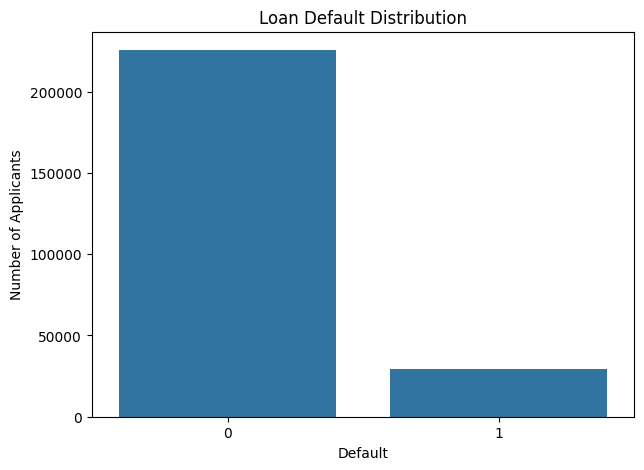

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Default')

plt.title('Loan Default Distribution')
plt.xlabel('Default')
plt.ylabel('Number of Applicants')
plt.show()

In [16]:
# Statistical summary
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [17]:
df.describe(include='object')

,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,ZTH91CGL0B,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


In [18]:
# Check Unique Values
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].unique())


LoanID
Number of unique values: 255347
['I38PQUQS96' 'HPSK72WA7R' 'C1OZ6DPJ8Y' ... 'XQK1UUUNGP' 'JAO28CPL4H'
 'ZTH91CGL0B']

Education
Number of unique values: 4
["Bachelor's" "Master's" 'High School' 'PhD']

EmploymentType
Number of unique values: 4
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

MaritalStatus
Number of unique values: 3
['Divorced' 'Married' 'Single']

HasMortgage
Number of unique values: 2
['Yes' 'No']

HasDependents
Number of unique values: 2
['Yes' 'No']

LoanPurpose
Number of unique values: 5
['Other' 'Auto' 'Business' 'Home' 'Education']

HasCoSigner
Number of unique values: 2
['Yes' 'No']


## Phase 2 — Detailed Exploratory Data Analysis

This phase performs detailed exploratory data analysis of the credit-risk dataset, including numerical distributions, categorical relationships, default-rate analysis, correlation analysis, and outlier detection.

In [19]:
# ============================================
# DETAILED EDA — DATASET OVERVIEW
# ============================================

print("Detailed EDA Started")
print("=" * 50)

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

Detailed EDA Started
Number of rows: 255,347
Number of columns: 18

Column names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


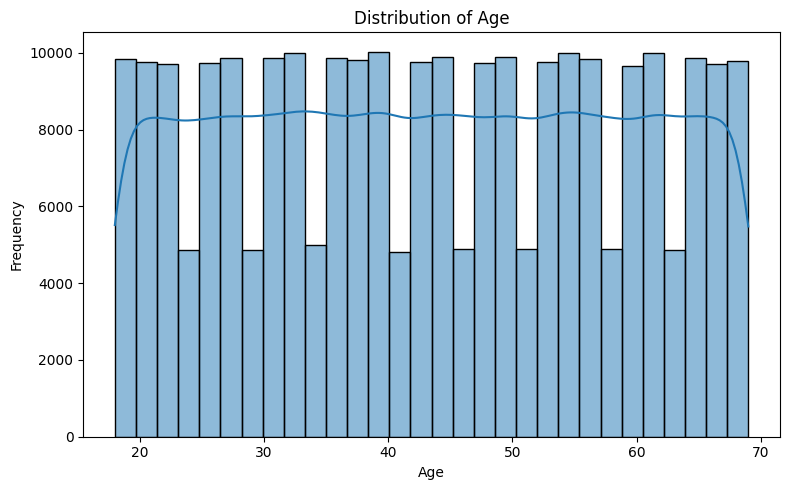

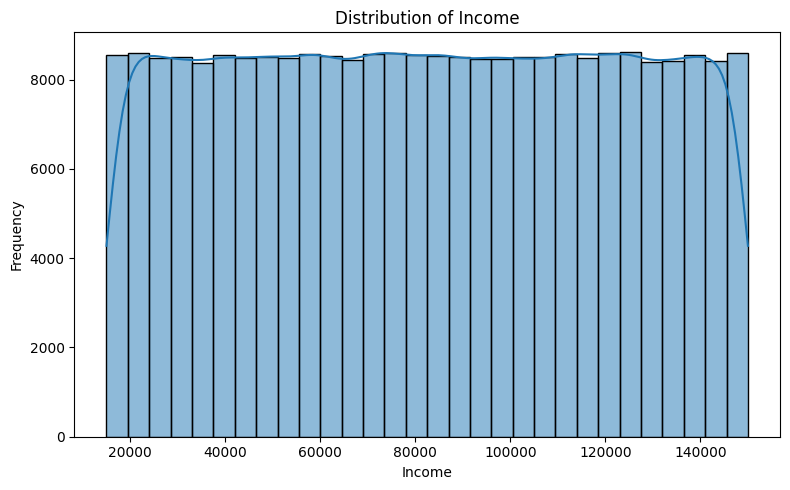

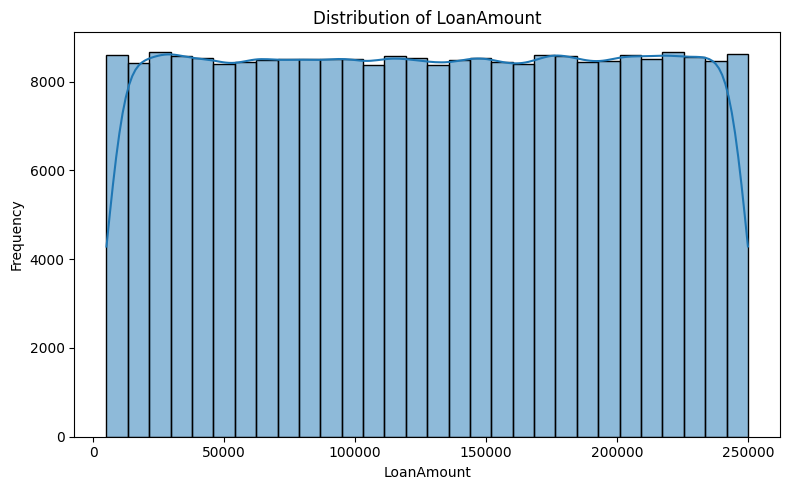

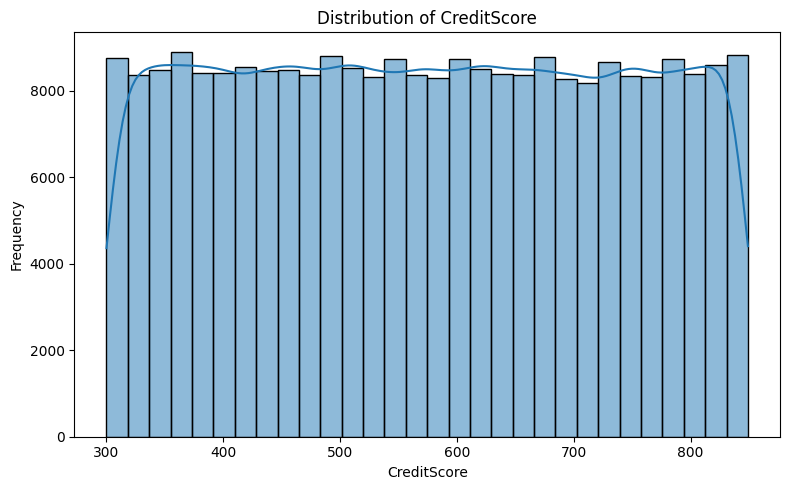

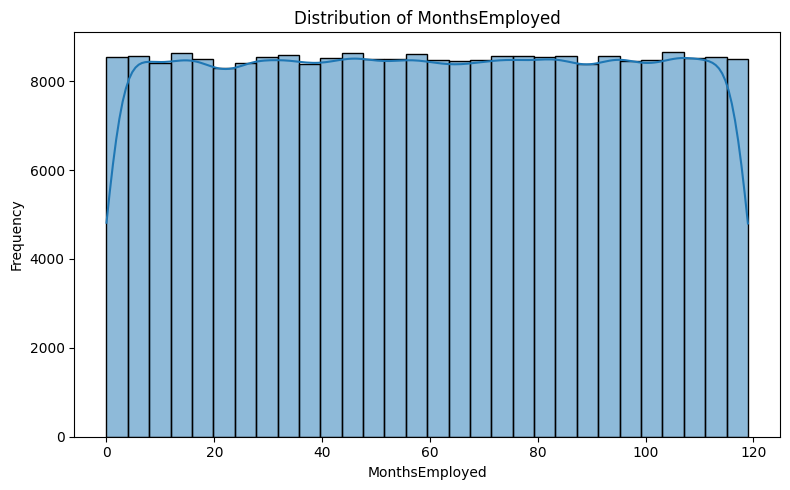

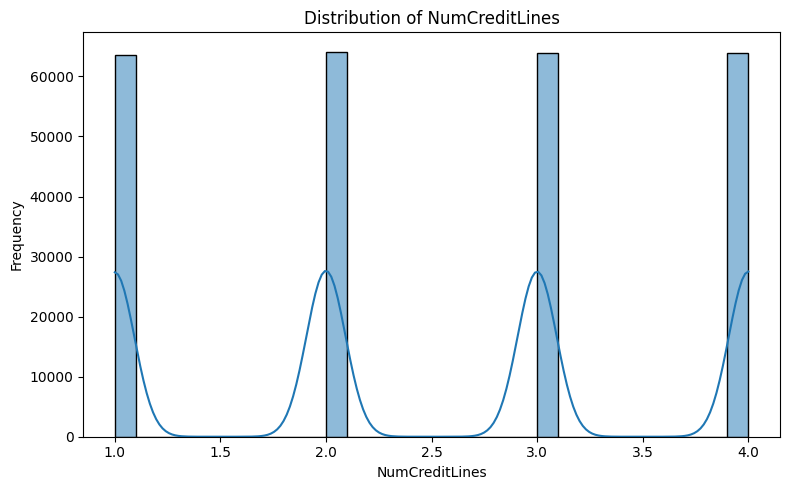

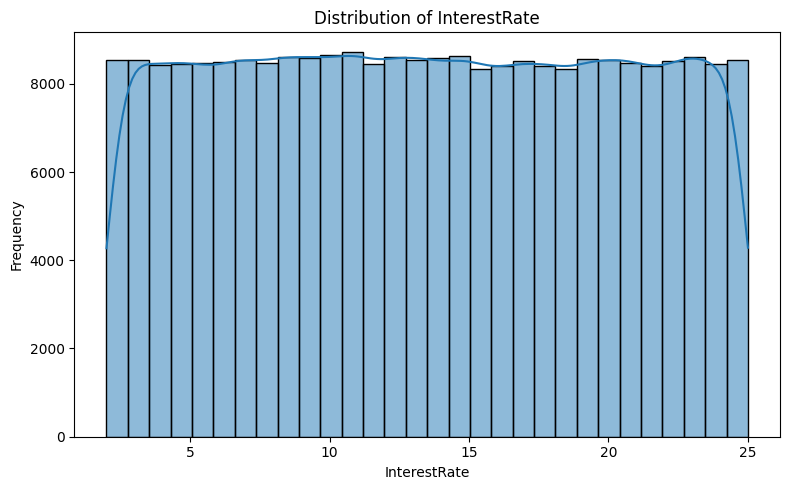

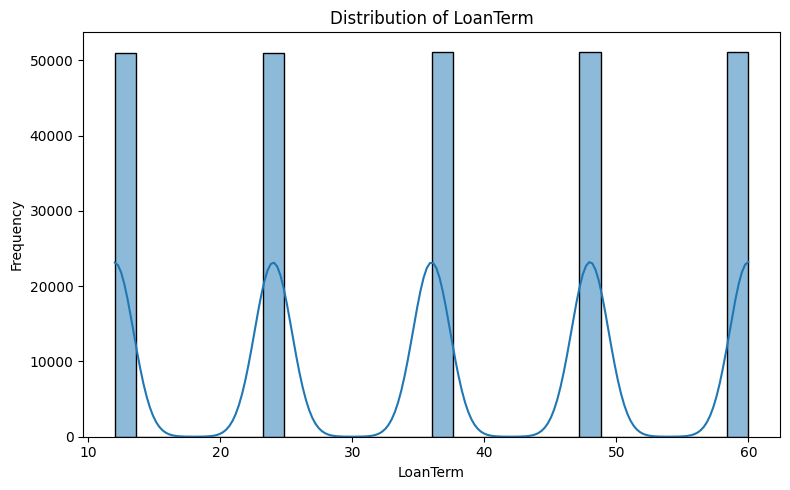

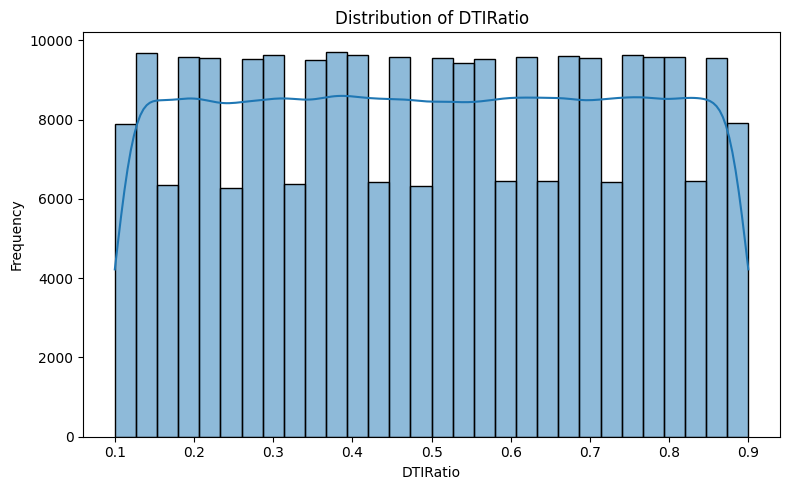

In [20]:
# ============================================
# NUMERICAL FEATURE DISTRIBUTIONS
# ============================================

numerical_features = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

for column in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

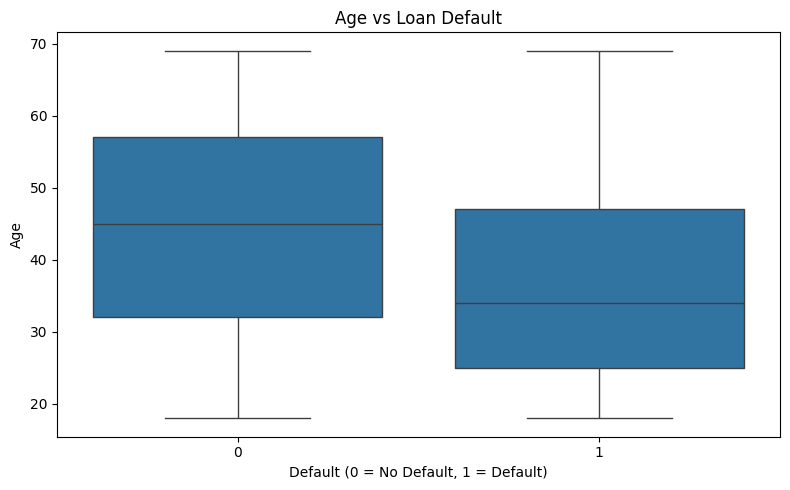

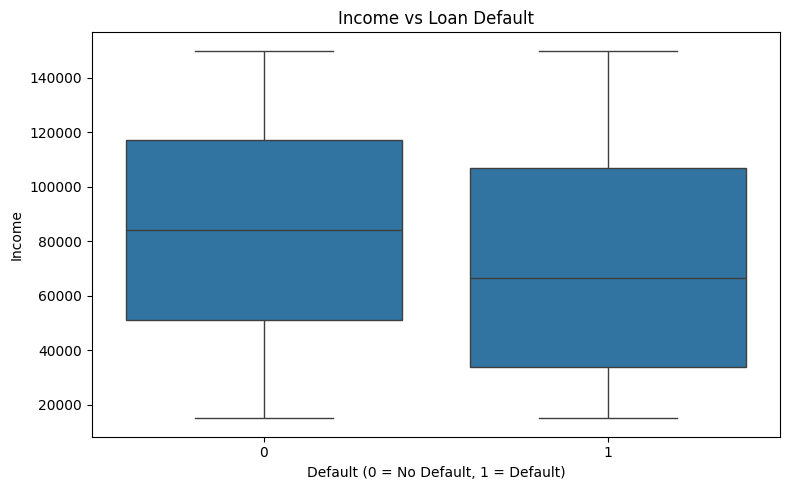

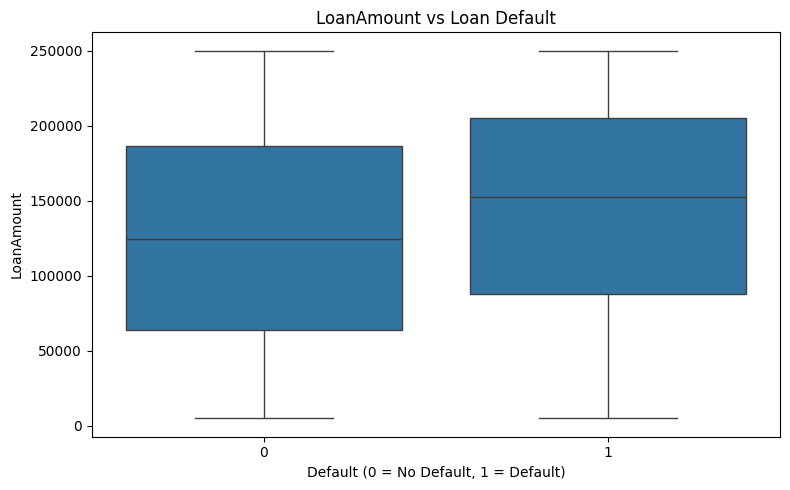

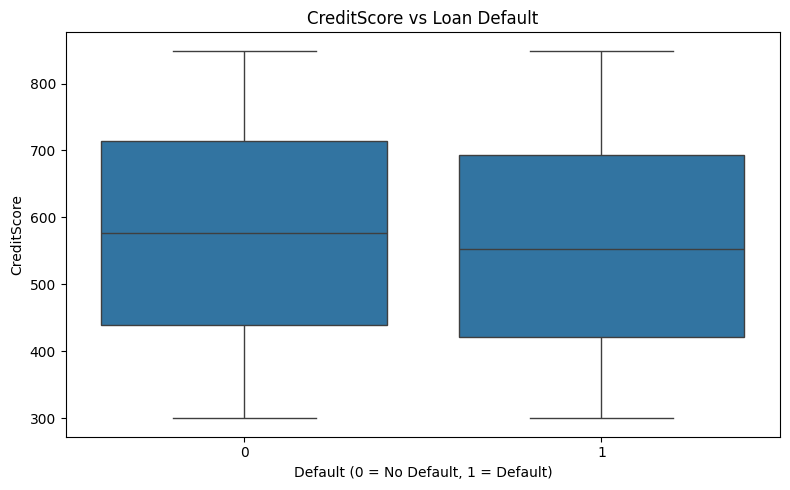

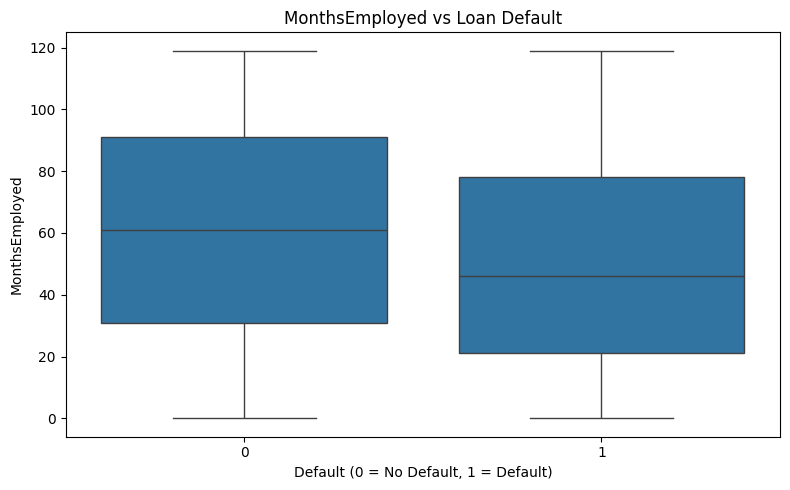

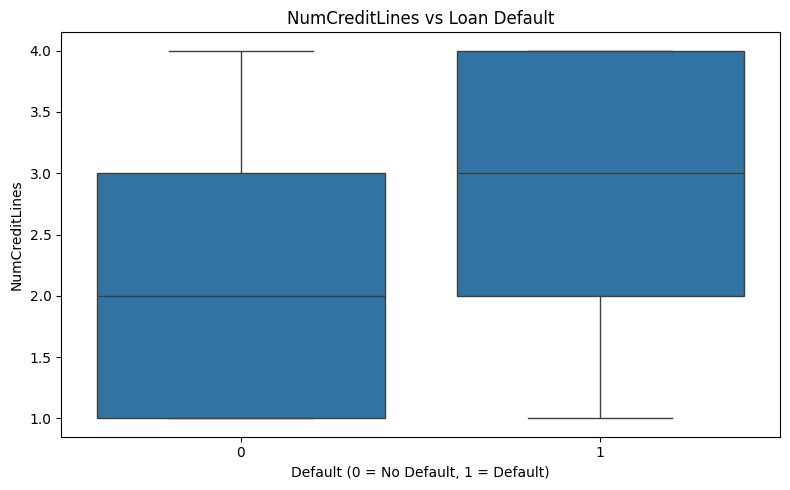

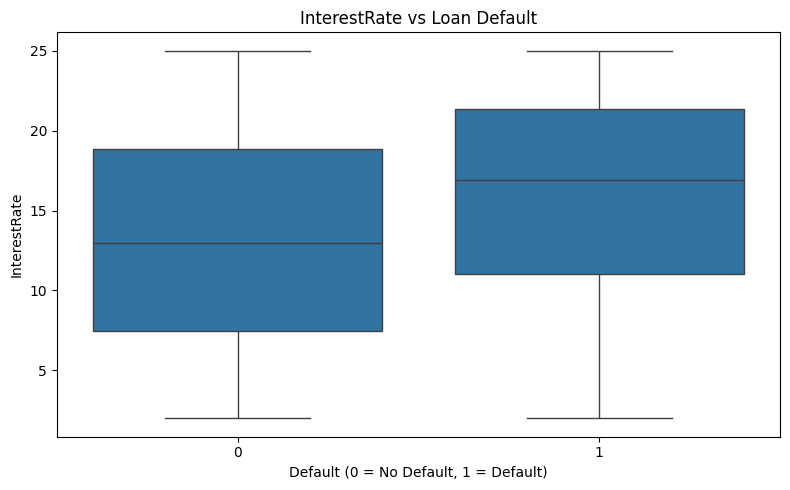

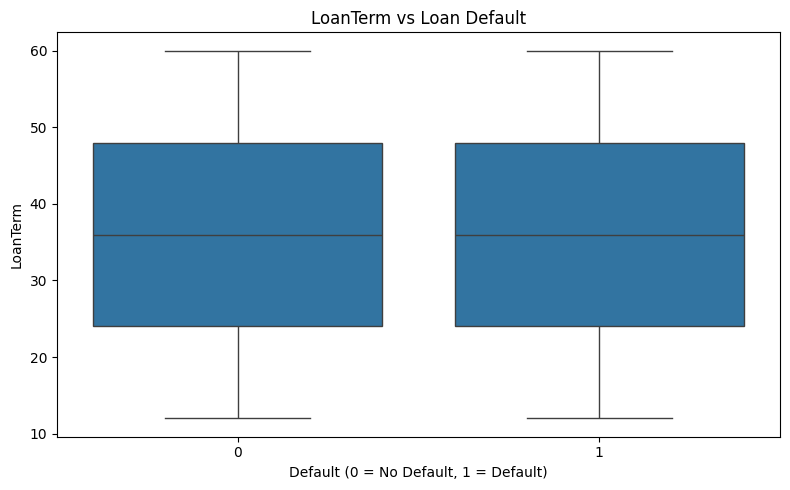

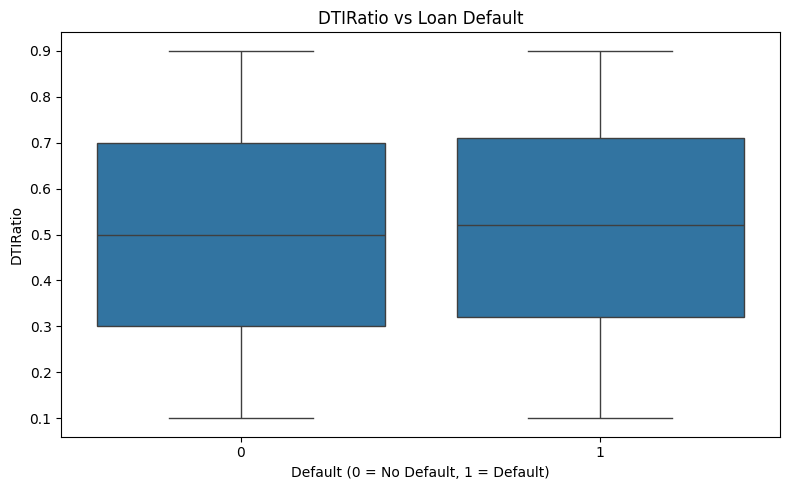

In [21]:
# ============================================
# NUMERICAL FEATURES VS DEFAULT
# ============================================

for column in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='Default',
        y=column
    )

    plt.title(f'{column} vs Loan Default')
    plt.xlabel('Default (0 = No Default, 1 = Default)')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

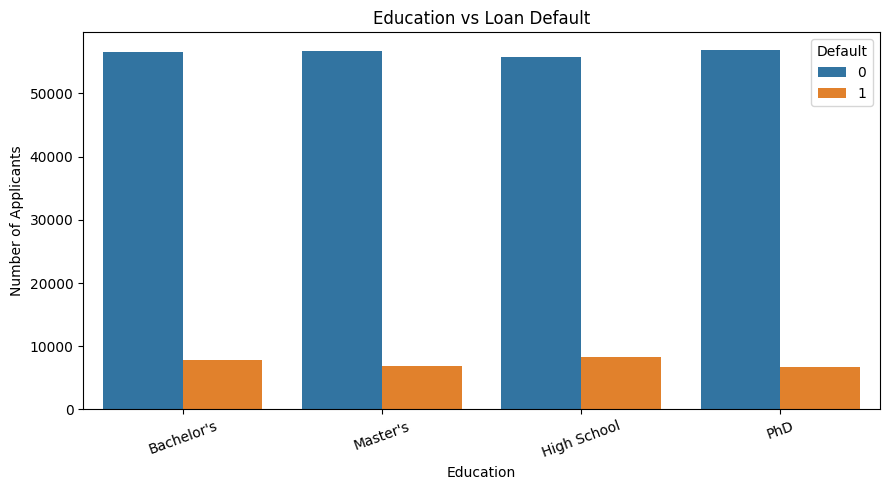

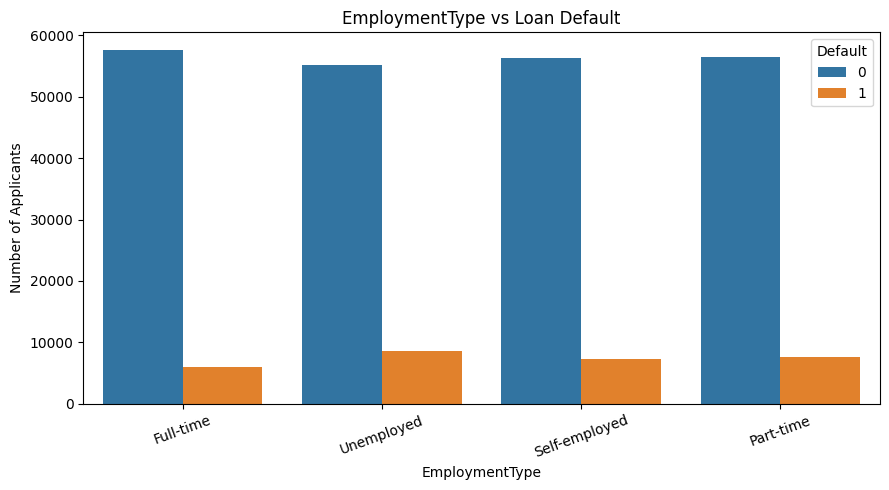

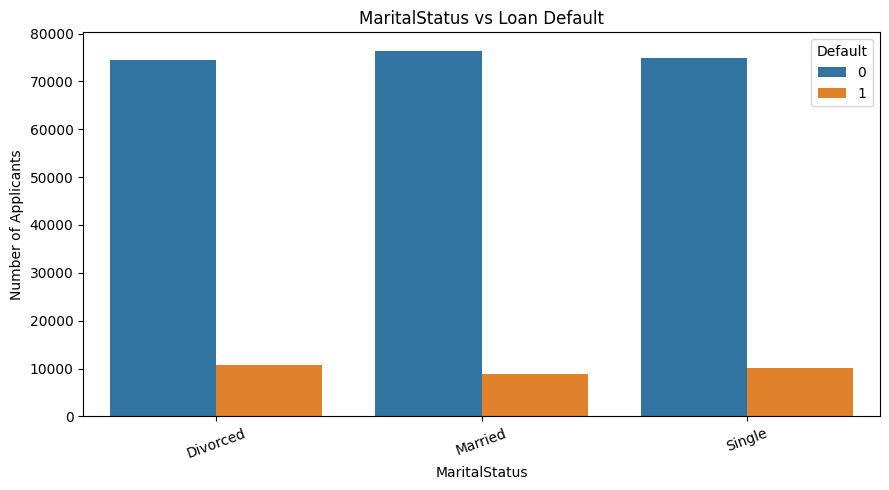

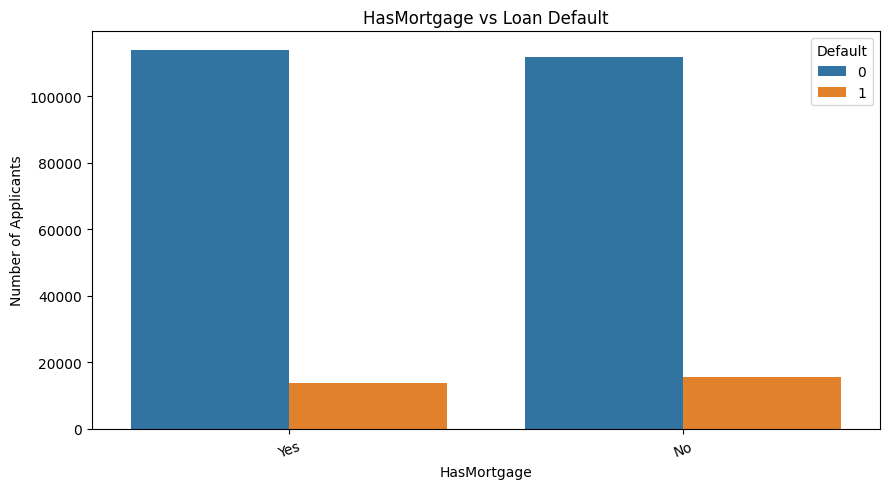

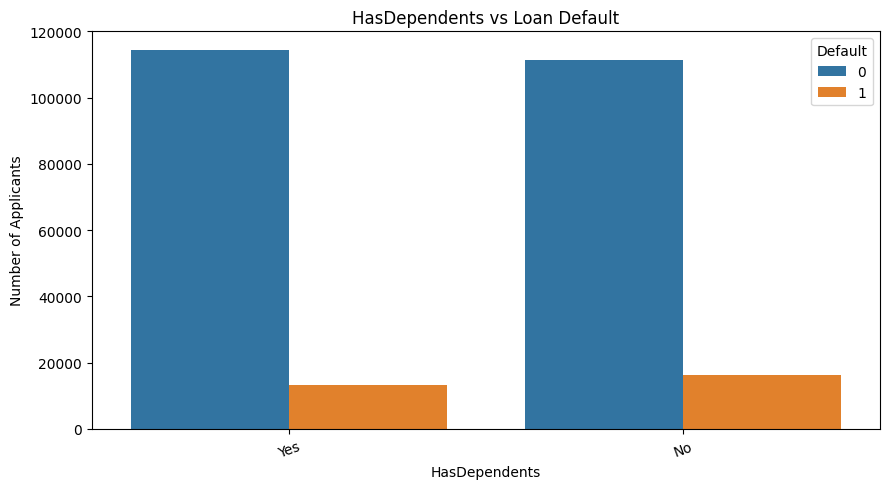

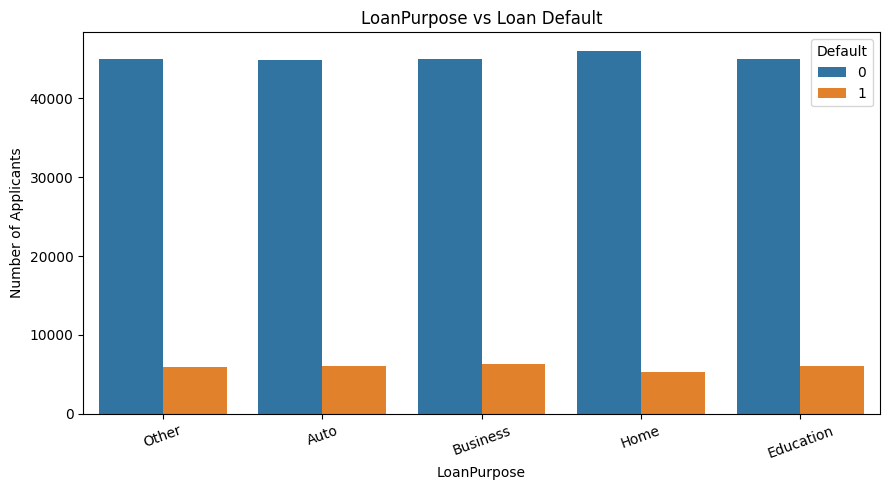

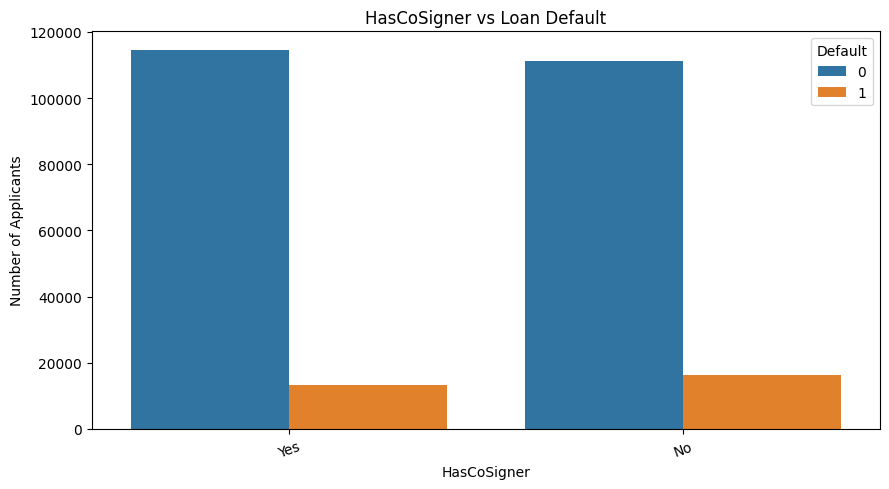

In [22]:
# ============================================
# CATEGORICAL FEATURES VS DEFAULT
# ============================================

categorical_features = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

for column in categorical_features:
    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df,
        x=column,
        hue='Default'
    )

    plt.title(f'{column} vs Loan Default')
    plt.xlabel(column)
    plt.ylabel('Number of Applicants')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


Default Rate by Education
Education
High School    12.88
Bachelor's     12.10
Master's       10.87
PhD            10.59
Name: Default, dtype: float64


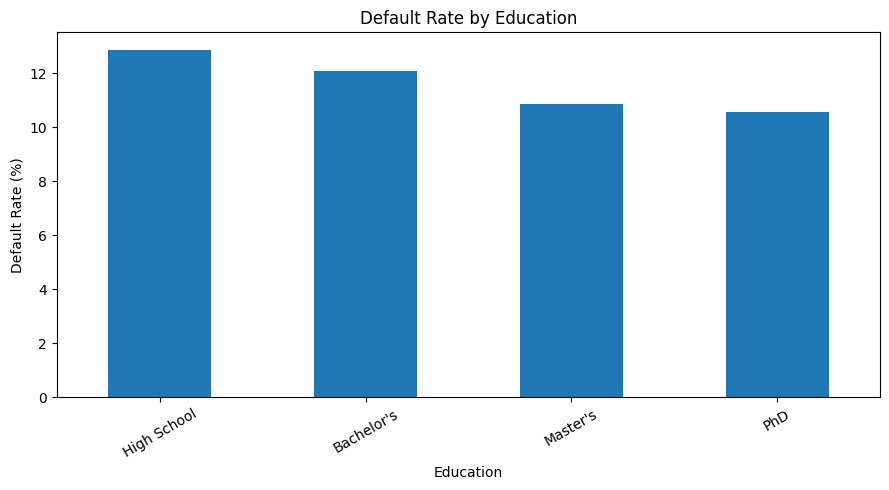


Default Rate by EmploymentType
EmploymentType
Unemployed       13.55
Part-time        11.97
Self-employed    11.46
Full-time         9.46
Name: Default, dtype: float64


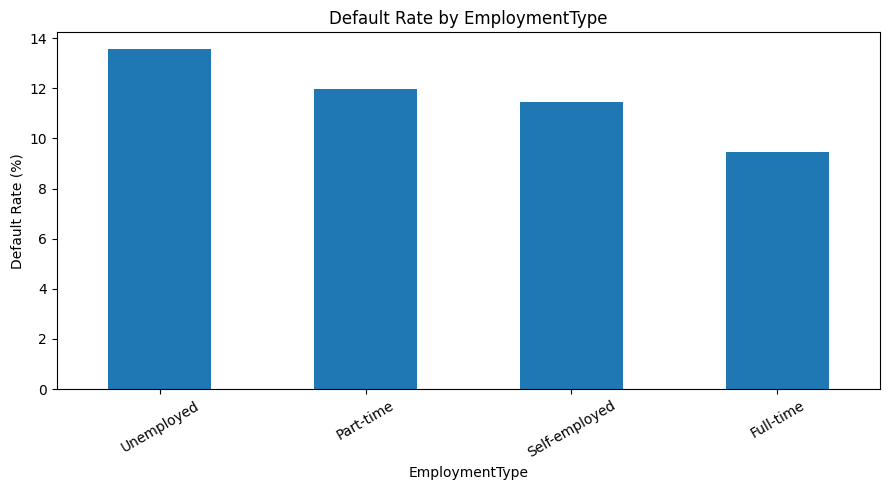


Default Rate by MaritalStatus
MaritalStatus
Divorced    12.53
Single      11.91
Married     10.40
Name: Default, dtype: float64


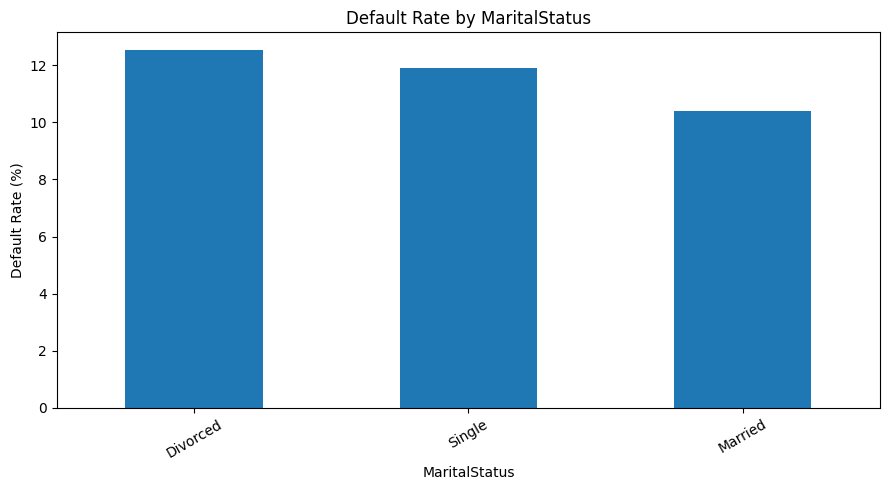


Default Rate by HasMortgage
HasMortgage
No     12.35
Yes    10.88
Name: Default, dtype: float64


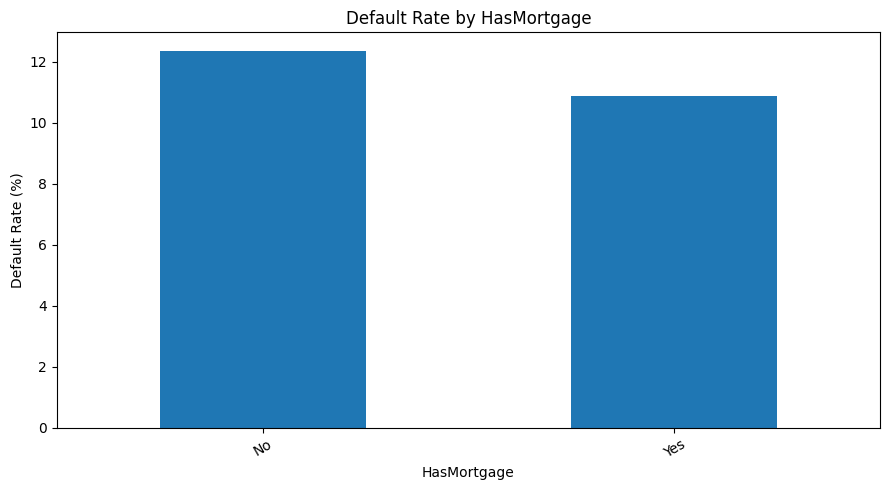


Default Rate by HasDependents
HasDependents
No     12.72
Yes    10.50
Name: Default, dtype: float64


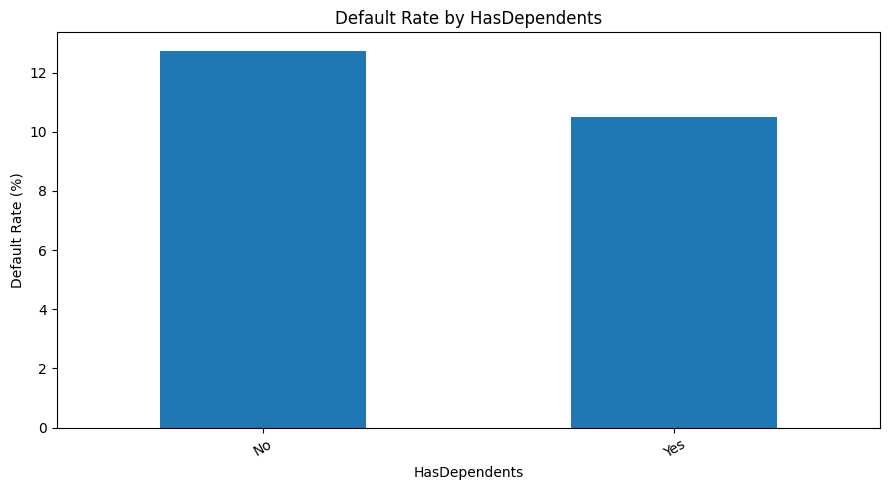


Default Rate by LoanPurpose
LoanPurpose
Business     12.33
Auto         11.88
Education    11.84
Other        11.79
Home         10.23
Name: Default, dtype: float64


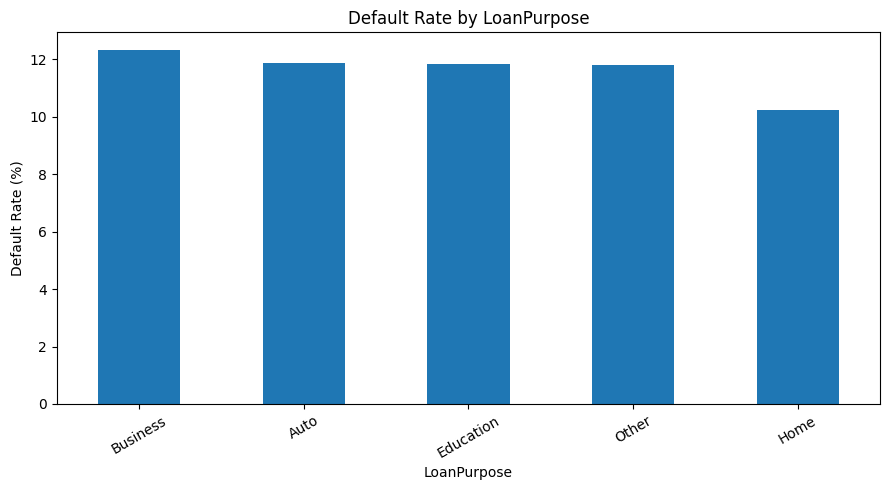


Default Rate by HasCoSigner
HasCoSigner
No     12.87
Yes    10.36
Name: Default, dtype: float64


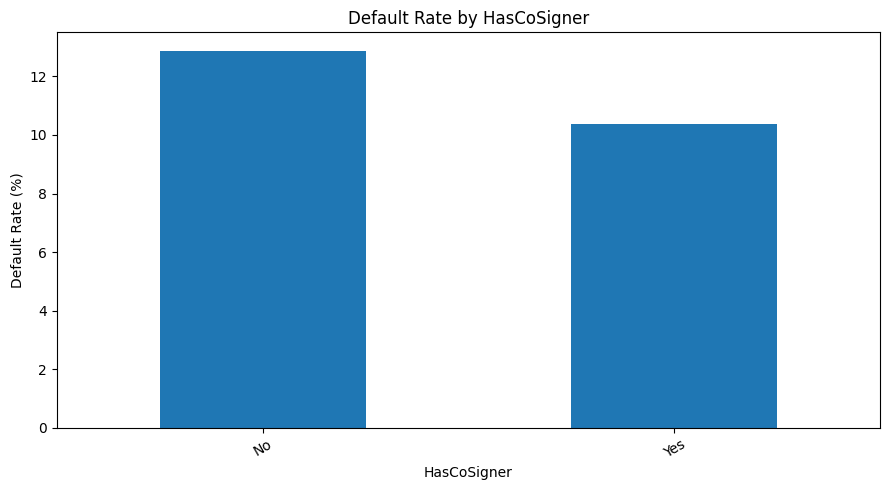

In [23]:
# ============================================
# DEFAULT RATE BY CATEGORICAL FEATURES
# ============================================

for column in categorical_features:

    default_rate = (
        df.groupby(column)['Default']
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print("\n" + "=" * 60)
    print(f"Default Rate by {column}")
    print("=" * 60)
    print(default_rate.round(2))

    plt.figure(figsize=(9, 5))

    default_rate.plot(kind='bar')

    plt.title(f'Default Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

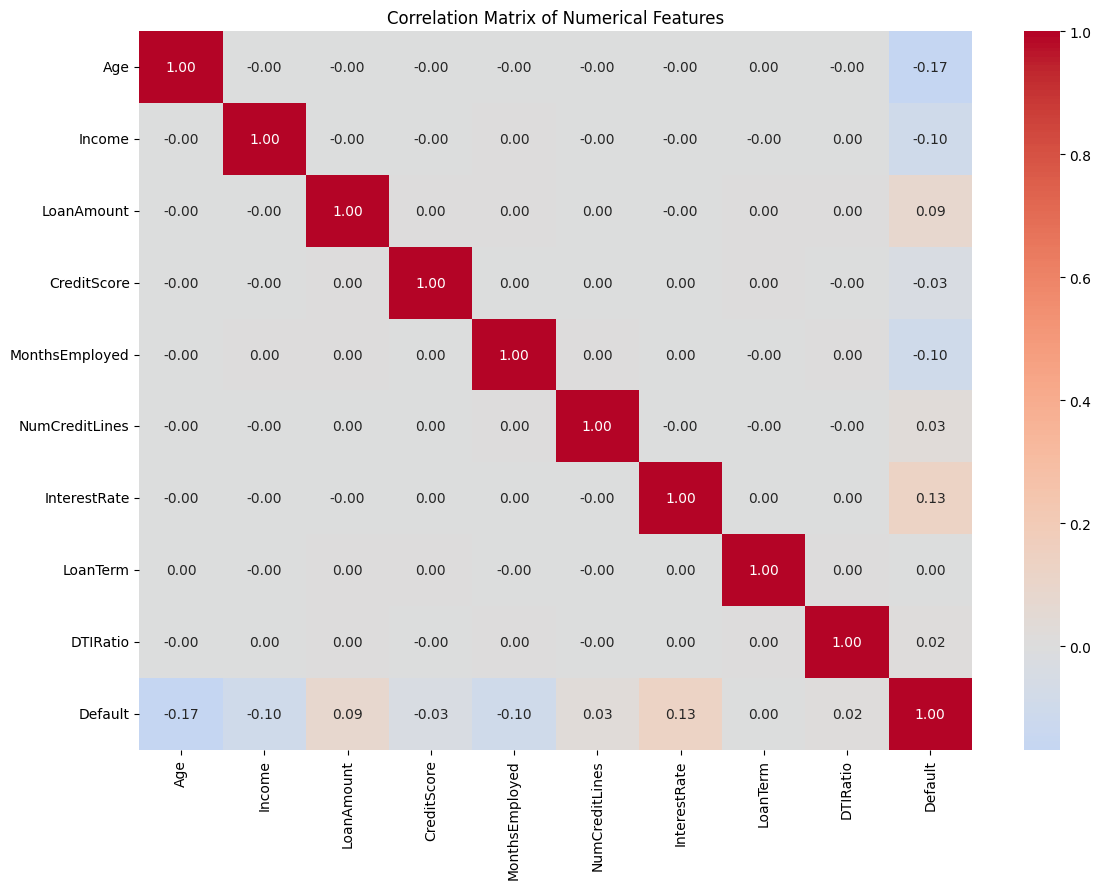

In [24]:
# ============================================
# CORRELATION MATRIX
# ============================================

correlation_features = numerical_features + ['Default']

correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [25]:
# ============================================
# CORRELATION WITH DEFAULT
# ============================================

default_correlations = (
    correlation_matrix['Default']
    .drop('Default')
    .sort_values(key=abs, ascending=False)
)

print("Correlation of Numerical Features with Default")
print("=" * 55)
print(default_correlations.round(4))

Correlation of Numerical Features with Default
Age              -0.1678
InterestRate      0.1313
Income           -0.0991
MonthsEmployed   -0.0974
LoanAmount        0.0867
CreditScore      -0.0342
NumCreditLines    0.0283
DTIRatio          0.0192
LoanTerm          0.0005
Name: Default, dtype: float64


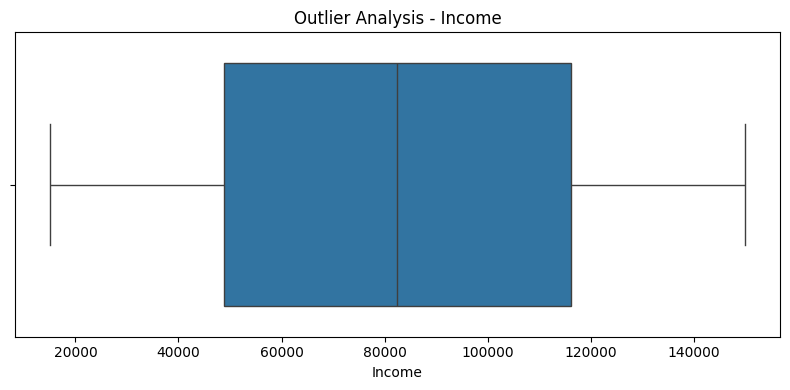

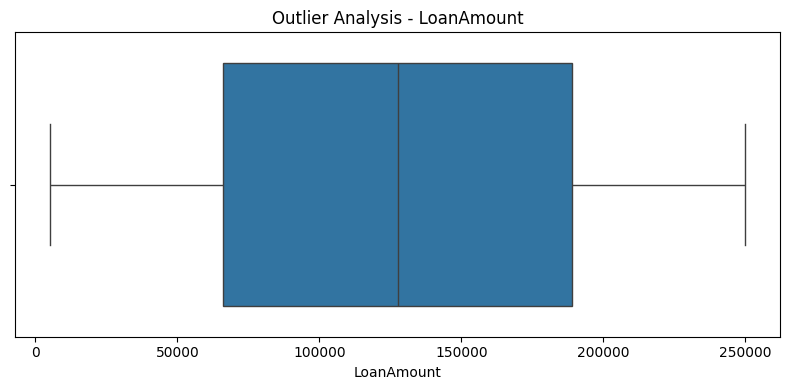

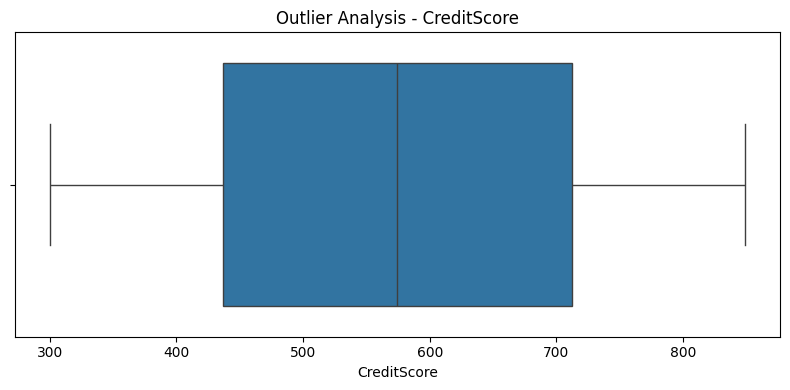

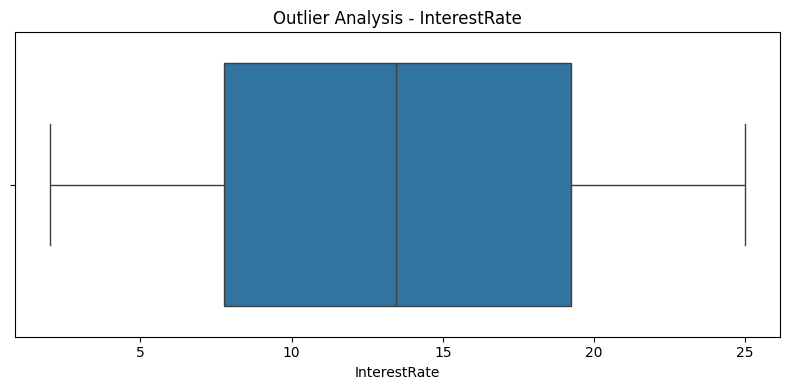

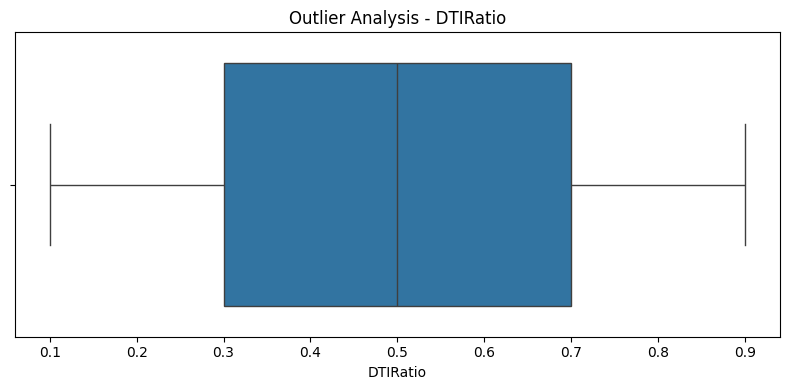

In [26]:
# ============================================
# OUTLIER ANALYSIS
# ============================================

outlier_features = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'InterestRate',
    'DTIRatio'
]

for column in outlier_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f'Outlier Analysis - {column}')
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## EDA Findings Summary

The dataset contains 255,347 loan applications with 18 original features.
There are no missing values and no duplicate rows.

The target variable, Default, is imbalanced, with approximately 88.39%
non-default cases and 11.61% default cases.

The numerical analysis examined the distributions of applicant and loan
characteristics, their relationship with loan default, correlations,
and potential outliers.

Among the numerical variables, Age has the strongest negative correlation
with Default (-0.1678), while InterestRate has the strongest positive
correlation with Default (0.1313). Income and MonthsEmployed also show
negative correlations with Default, while LoanAmount shows a positive
correlation.

Correlation analysis is used as an exploratory measure and does not imply
causation. Model-based analysis will be used later to evaluate predictive
importance and relationships that may be nonlinear.

In [27]:
#2.1 Feature Engineering Pipeline

def engineer_features(data):
    df_feat = data.copy()

    # ============================================
    # FINANCIAL RATIO FEATURES
    # ============================================

    df_feat['MonthlyIncome'] = df_feat['Income'] / 12

    df_feat['EstimatedMonthlyDebt'] = (
        df_feat['MonthlyIncome'] * df_feat['DTIRatio']
    )

    df_feat['LoanToIncome'] = (
        df_feat['LoanAmount'] / (df_feat['Income'] + 1)
    )

    # ============================================
    # RISK INDICATORS
    # ============================================

    df_feat['CreditToAgeRatio'] = (
        df_feat['CreditScore'] / (df_feat['Age'] + 1)
    )

    df_feat['EmploymentStability'] = (
        df_feat['MonthsEmployed'] /
        (df_feat['Age'] * 12 + 1)
    )

    df_feat['HighRiskCombo'] = (
        (df_feat['DTIRatio'] > 0.6) &
        (df_feat['CreditScore'] < 580)
    ).astype(int)

    # ============================================
    # ADDITIONAL CREDIT RISK FEATURES
    # ============================================


    df_feat['InterestDebtStress'] = (
        df_feat['InterestRate'] * df_feat['DTIRatio']
    )

    df_feat['LoanPerCreditLine'] = (
        df_feat['LoanAmount'] /
        (df_feat['NumCreditLines'] + 1)
    )

    return df_feat


df_engineered = engineer_features(df)

print("Features engineered. New shape:", df_engineered.shape)

Features engineered. New shape: (255347, 26)


In [28]:
# ============================================
# UPDATED FEATURE ENGINEERING VERIFICATION
# ============================================

engineered_features = [
    'MonthlyIncome',
    'EstimatedMonthlyDebt',
    'LoanToIncome',
    'CreditToAgeRatio',
    'EmploymentStability',
    'HighRiskCombo',
    'InterestDebtStress',
    'LoanPerCreditLine'
]

print("Updated Feature Engineering Verification")
print("=" * 55)

for feature in engineered_features:
    print(f"{feature}: {'EXISTS' if feature in df_engineered.columns else 'MISSING'}")

print("\nOriginal Shape:", df.shape)
print("Engineered Shape:", df_engineered.shape)

print("\nMissing Values:")
print(df_engineered[engineered_features].isnull().sum())

print("\nInfinite Values:")
print(
    df_engineered[engineered_features]
    .isin([float('inf'), float('-inf')])
    .sum()
)

Updated Feature Engineering Verification
MonthlyIncome: EXISTS
EstimatedMonthlyDebt: EXISTS
LoanToIncome: EXISTS
CreditToAgeRatio: EXISTS
EmploymentStability: EXISTS
HighRiskCombo: EXISTS
InterestDebtStress: EXISTS
LoanPerCreditLine: EXISTS

Original Shape: (255347, 18)
Engineered Shape: (255347, 26)

Missing Values:
MonthlyIncome           0
EstimatedMonthlyDebt    0
LoanToIncome            0
CreditToAgeRatio        0
EmploymentStability     0
HighRiskCombo           0
InterestDebtStress      0
LoanPerCreditLine       0
dtype: int64

Infinite Values:
MonthlyIncome           0
EstimatedMonthlyDebt    0
LoanToIncome            0
CreditToAgeRatio        0
EmploymentStability     0
HighRiskCombo           0
InterestDebtStress      0
LoanPerCreditLine       0
dtype: int64


In [29]:
# ============================================
# ENGINEERED FEATURE QUALITY CHECK
# ============================================

print("Engineered Feature Quality Check")
print("=" * 55)

print("\nMissing Values:")
print(df_engineered[engineered_features].isnull().sum())

print("\nInfinite Values:")
print(
    df_engineered[engineered_features]
    .isin([float('inf'), float('-inf')])
    .sum()
)

print("\nSummary Statistics:")
display(
    df_engineered[engineered_features]
    .describe()
)

Engineered Feature Quality Check

Missing Values:
MonthlyIncome           0
EstimatedMonthlyDebt    0
LoanToIncome            0
CreditToAgeRatio        0
EmploymentStability     0
HighRiskCombo           0
InterestDebtStress      0
LoanPerCreditLine       0
dtype: int64

Infinite Values:
MonthlyIncome           0
EstimatedMonthlyDebt    0
LoanToIncome            0
CreditToAgeRatio        0
EmploymentStability     0
HighRiskCombo           0
InterestDebtStress      0
LoanPerCreditLine       0
dtype: int64

Summary Statistics:


,MonthlyIncome,EstimatedMonthlyDebt,LoanToIncome,CreditToAgeRatio,EmploymentStability,HighRiskCombo,InterestDebtStress,LoanPerCreditLine
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,6874.942050,3439.083029,2.177423,14.769994,0.131232,0.189041,6.750130,40899.981858
std,3246.917811,2393.724010,2.178254,7.338933,0.098498,0.391542,4.806461,28123.090561
min,1250.000000,125.150000,0.033749,4.285714,0.000000,0.000000,0.201000,1001.800000
25%,4068.791667,1485.260000,0.803619,9.461538,0.056604,0.000000,2.831400,18882.800000
50%,6872.166667,2842.843333,1.546704,12.900000,0.113924,0.000000,5.532700,36456.000000
75%,9684.916667,4941.755417,2.671710,18.272727,0.178517,0.000000,9.729000,56073.333333
max,12499.916667,11244.375000,16.531360,44.684211,0.548387,1.000000,22.500000,124998.500000


In [30]:
# ============================================
# ENGINEERED FEATURES VS DEFAULT
# ============================================

engineered_correlation = (
    df_engineered[engineered_features + ['Default']]
    .corr()['Default']
    .drop('Default')
    .sort_values(key=abs, ascending=False)
)

print("Correlation of Engineered Features with Default")
print("=" * 55)
print(engineered_correlation.round(4))

Correlation of Engineered Features with Default
LoanToIncome            0.1790
CreditToAgeRatio        0.1121
InterestDebtStress      0.1053
MonthlyIncome          -0.0991
EstimatedMonthlyDebt   -0.0553
LoanPerCreditLine       0.0550
HighRiskCombo           0.0203
EmploymentStability     0.0032
Name: Default, dtype: float64


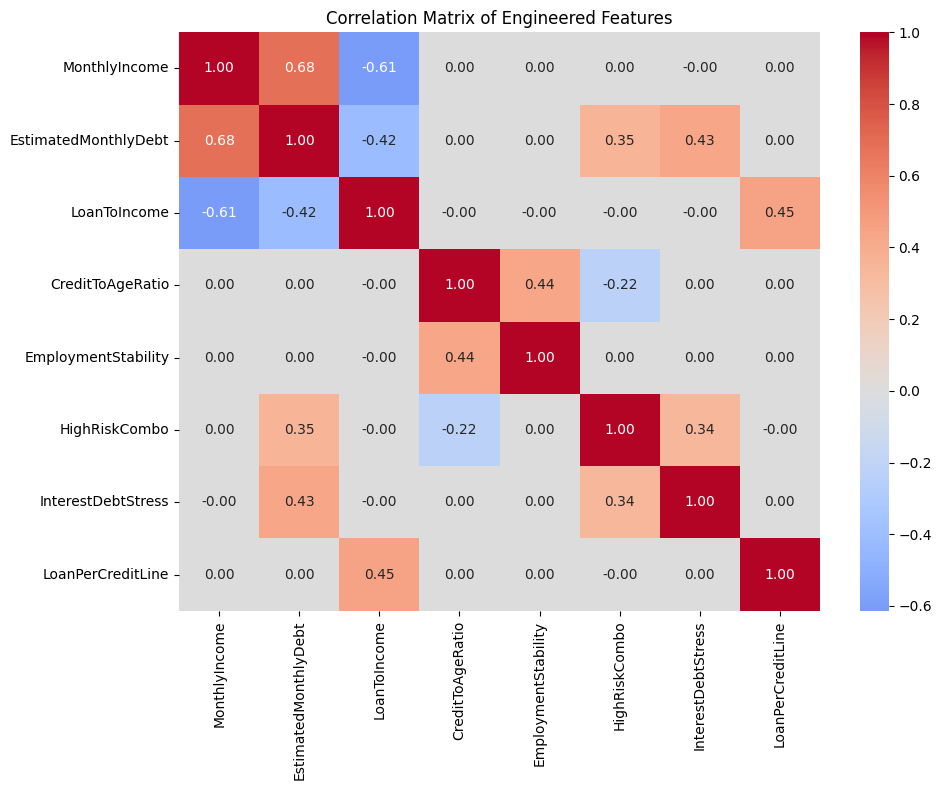

In [31]:
# ============================================
# ENGINEERED FEATURE CORRELATION MATRIX
# ============================================

engineered_corr_matrix = df_engineered[engineered_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    engineered_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()

In [32]:
# ============================================
# ENGINEERED FEATURE STATISTICS
# ============================================

print("Engineered Feature Statistics")
print("=" * 55)

display(
    df_engineered[engineered_features].describe().T
)

Engineered Feature Statistics


,count,mean,std,min,25%,50%,75%,max
MonthlyIncome,255347.0,6874.942050,3246.917811,1250.000000,4068.791667,6872.166667,9684.916667,12499.916667
EstimatedMonthlyDebt,255347.0,3439.083029,2393.724010,125.150000,1485.260000,2842.843333,4941.755417,11244.375000
LoanToIncome,255347.0,2.177423,2.178254,0.033749,0.803619,1.546704,2.671710,16.531360
CreditToAgeRatio,255347.0,14.769994,7.338933,4.285714,9.461538,12.900000,18.272727,44.684211
EmploymentStability,255347.0,0.131232,0.098498,0.000000,0.056604,0.113924,0.178517,0.548387
HighRiskCombo,255347.0,0.189041,0.391542,0.000000,0.000000,0.000000,0.000000,1.000000
InterestDebtStress,255347.0,6.750130,4.806461,0.201000,2.831400,5.532700,9.729000,22.500000
LoanPerCreditLine,255347.0,40899.981858,28123.090561,1001.800000,18882.800000,36456.000000,56073.333333,124998.500000


In [33]:
# ============================================
# PREPROCESSING — COLUMN IDENTIFICATION
# ============================================

target_column = 'Default'

# Remove target and identifier
feature_columns = [
    column for column in df_engineered.columns
    if column not in [target_column, 'LoanID']
]

X = df_engineered[feature_columns]
y = df_engineered[target_column]

numerical_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Preprocessing Column Identification")
print("=" * 55)

print("\nTotal Features:", len(feature_columns))

print("\nNumerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Preprocessing Column Identification

Total Features: 24

Numerical Features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'MonthlyIncome', 'EstimatedMonthlyDebt', 'LoanToIncome', 'CreditToAgeRatio', 'EmploymentStability', 'HighRiskCombo', 'InterestDebtStress', 'LoanPerCreditLine']

Categorical Features:
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

X Shape: (255347, 24)
y Shape: (255347,)


In [34]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split")
print("=" * 55)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train/Test Split
Training samples: 204277
Testing samples: 51070

Training target distribution:
Default
0    0.8839
1    0.1161
Name: proportion, dtype: float64

Testing target distribution:
Default
0    0.8839
1    0.1161
Name: proportion, dtype: float64


In [35]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer, numerical_columns),
        ('categorical', categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [36]:
# ============================================
# FIT PREPROCESSOR ON TRAINING DATA
# ============================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print("=" * 55)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Preprocessing completed successfully.
Original X_train shape: (204277, 24)
Processed X_train shape: (204277, 39)
Original X_test shape: (51070, 24)
Processed X_test shape: (51070, 39)


In [37]:
# ============================================
# PREPROCESSING VERIFICATION
# ============================================

import numpy as np

print("Preprocessing Verification")
print("=" * 55)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nMissing values in processed training data:")
print(np.isnan(X_train_processed).sum())

print("\nMissing values in processed testing data:")
print(np.isnan(X_test_processed).sum())

print("\nInfinite values in processed training data:")
print(np.isinf(X_train_processed).sum())

print("\nInfinite values in processed testing data:")
print(np.isinf(X_test_processed).sum())

Preprocessing Verification
Processed training shape: (204277, 39)
Processed testing shape: (51070, 39)

Missing values in processed training data:
0

Missing values in processed testing data:
0

Infinite values in processed training data:
0

Infinite values in processed testing data:
0


In [38]:
# ============================================
# MODEL COMPARISON — 3 ALGORITHMS
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),

    'HistGradient Boosting': HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        random_state=42
    )
}

trained_models = {}

print("Training models...")
print("=" * 55)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_processed, y_train)

    trained_models[name] = model

    print(f"{name} completed.")

print("\nAll models trained successfully.")

print("\nAvailable trained models:")
for name in trained_models:
    print(f"{name}: {trained_models[name] is not None}")

Training models...

Training Logistic Regression...
Logistic Regression completed.

Training Random Forest...
Random Forest completed.

Training HistGradient Boosting...
HistGradient Boosting completed.

All models trained successfully.

Available trained models:
Logistic Regression: True
Random Forest: True
HistGradient Boosting: True


In [39]:
# ============================================
# MODEL COMPARISON — TEST SET EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

model_results = []

print("Evaluating trained models...")
print("=" * 70)

for name, model in trained_models.items():

    # Generate predictions
    y_pred = model.predict(X_test_processed)

    # Generate probability predictions
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    model_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

model_comparison = pd.DataFrame(model_results)

# Sort by ROC-AUC
model_comparison = model_comparison.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

print("\nModel Comparison Results")
print("=" * 80)

display(model_comparison.round(4))

Evaluating trained models...

Model Comparison Results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8869,0.6168,0.0695,0.1249,0.7617,0.3367
1,HistGradient Boosting,0.8865,0.6053,0.0659,0.1189,0.7572,0.3290
2,Random Forest,0.8854,0.6471,0.0297,0.0567,0.7416,0.3050


In [40]:
# ============================================
# MODEL VARIABLES VERIFICATION
# ============================================

print("Model variables verification")
print("=" * 55)

print("trained_models exists:", 'trained_models' in globals())
print("model_comparison exists:", 'model_comparison' in globals())

print("\nAvailable models:")
for name in trained_models:
    print(f"- {name}")

print("\nBest model based on ROC-AUC:")

best_model_name = model_comparison.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Model:", best_model_name)
print("ROC-AUC:", round(model_comparison.iloc[0]['ROC-AUC'], 4))

Model variables verification
trained_models exists: True
model_comparison exists: True

Available models:
- Logistic Regression
- Random Forest
- HistGradient Boosting

Best model based on ROC-AUC:
Model: Logistic Regression
ROC-AUC: 0.7617


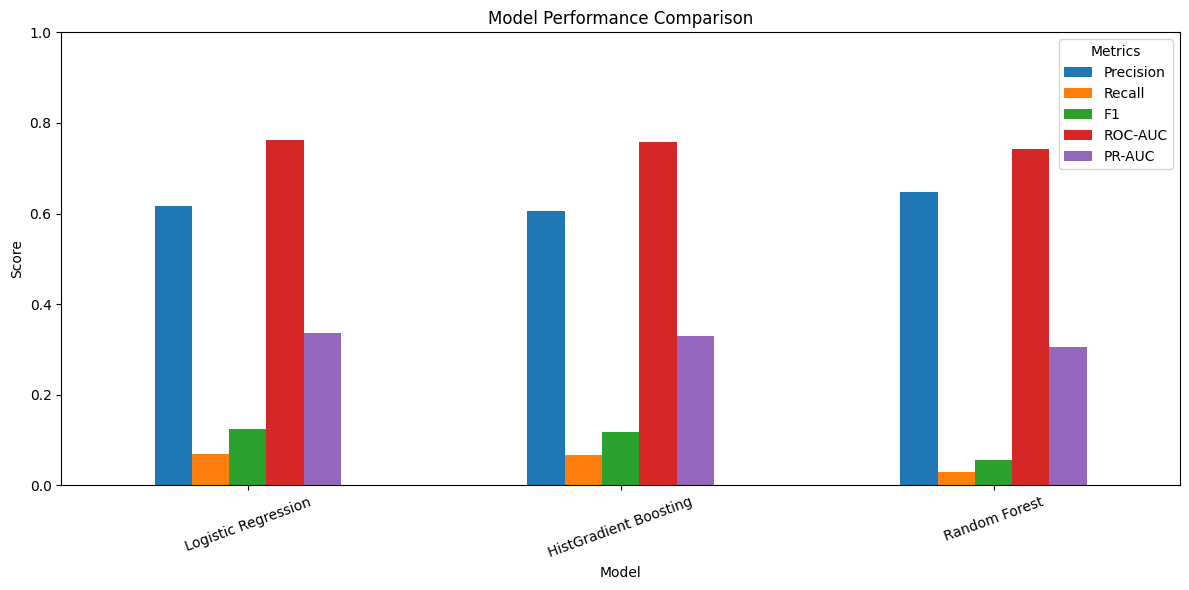

In [41]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

import matplotlib.pyplot as plt

metrics_to_plot = [
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC'
]

# Use the existing model_comparison DataFrame
results_plot = model_comparison.set_index('Model')[metrics_to_plot]

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

In [42]:
# ============================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

print("5-Fold Stratified Cross-Validation")
print("=" * 65)

for name, model in models.items():

    print(f"\nEvaluating {name}...")

    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = {
        'ROC-AUC Mean': scores['test_roc_auc'].mean(),
        'ROC-AUC Std': scores['test_roc_auc'].std(),
        'PR-AUC Mean': scores['test_average_precision'].mean(),
        'PR-AUC Std': scores['test_average_precision'].std(),
        'Precision Mean': scores['test_precision'].mean(),
        'Recall Mean': scores['test_recall'].mean(),
        'F1 Mean': scores['test_f1'].mean()
    }

cv_results_df = pd.DataFrame(cv_results).T

display(cv_results_df.round(4))

5-Fold Stratified Cross-Validation

Evaluating Logistic Regression...

Evaluating Random Forest...


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Evaluating HistGradient Boosting...


,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Precision Mean,Recall Mean,F1 Mean
Logistic Regression,0.7558,0.0031,0.3264,0.0042,0.6056,0.0677,0.1218
Random Forest,0.7347,0.0025,0.2944,0.0040,0.6363,0.0280,0.0536
HistGradient Boosting,0.7505,0.0024,0.3177,0.0029,0.5990,0.0615,0.1115


In [43]:
# ============================================
# CROSS-VALIDATION SUMMARY
# ============================================

print("Cross-Validation Summary")
print("=" * 65)

display(
    cv_results_df.sort_values(
        by='ROC-AUC Mean',
        ascending=False
    ).round(4)
)

Cross-Validation Summary


,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Precision Mean,Recall Mean,F1 Mean
Logistic Regression,0.7558,0.0031,0.3264,0.0042,0.6056,0.0677,0.1218
HistGradient Boosting,0.7505,0.0024,0.3177,0.0029,0.5990,0.0615,0.1115
Random Forest,0.7347,0.0025,0.2944,0.0040,0.6363,0.0280,0.0536


In [44]:
# ============================================
# CROSS-VALIDATION STABILITY
# ============================================

print("Cross-Validation Stability")
print("=" * 65)

for model_name in cv_results_df.index:

    mean_auc = cv_results_df.loc[model_name, 'ROC-AUC Mean']
    std_auc = cv_results_df.loc[model_name, 'ROC-AUC Std']

    print(
        f"{model_name}: "
        f"ROC-AUC = {mean_auc:.4f} ± {std_auc:.4f}"
    )

Cross-Validation Stability
Logistic Regression: ROC-AUC = 0.7558 ± 0.0031
Random Forest: ROC-AUC = 0.7347 ± 0.0025
HistGradient Boosting: ROC-AUC = 0.7505 ± 0.0024


In [45]:
# ============================================
# HYPERPARAMETER TUNING
# ============================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

param_distributions = {
    'C': loguniform(0.001, 100),
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [46]:
# ============================================
# RANDOMIZED SEARCH
# ============================================

random_search = RandomizedSearchCV(
    estimator=logistic_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting RandomizedSearchCV...")

random_search.fit(
    X_train_processed,
    y_train
)

print("\nHyperparameter tuning completed.")

Starting RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Hyperparameter tuning completed.


In [47]:
# ============================================
# BEST HYPERPARAMETERS
# ============================================

print("Best Hyperparameters")
print("=" * 55)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(random_search.best_score_, 4))

best_logistic_model = random_search.best_estimator_

Best Hyperparameters
Best Parameters:
{'C': np.float64(0.0745934328572655), 'class_weight': None, 'solver': 'liblinear'}

Best Cross-Validation ROC-AUC:
0.7559


In [48]:
# ============================================
# TUNED MODEL TEST EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

y_pred_tuned = best_logistic_model.predict(X_test_processed)
y_prob_tuned = best_logistic_model.predict_proba(X_test_processed)[:, 1]

tuned_results = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1': f1_score(y_test, y_pred_tuned, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned),
    'PR-AUC': average_precision_score(y_test, y_prob_tuned)
}

print("Tuned Logistic Regression — Test Results")
print("=" * 60)

for metric, value in tuned_results.items():
    print(f"{metric}: {value:.4f}")

Tuned Logistic Regression — Test Results
Accuracy: 0.8869
Precision: 0.6150
Recall: 0.0690
F1: 0.1240
ROC-AUC: 0.7617
PR-AUC: 0.3366


In [49]:
# ============================================
# BASELINE VS TUNED MODEL
# ============================================

# Get baseline Logistic Regression results
baseline_lr = model_comparison[
    model_comparison['Model'] == 'Logistic Regression'
].iloc[0]

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC',
        'PR-AUC'
    ],
    'Baseline Logistic Regression': [
        baseline_lr['Accuracy'],
        baseline_lr['Precision'],
        baseline_lr['Recall'],
        baseline_lr['F1'],
        baseline_lr['ROC-AUC'],
        baseline_lr['PR-AUC']
    ],
    'Tuned Logistic Regression': [
        tuned_results['Accuracy'],
        tuned_results['Precision'],
        tuned_results['Recall'],
        tuned_results['F1'],
        tuned_results['ROC-AUC'],
        tuned_results['PR-AUC']
    ]
})

print("Baseline vs Tuned Logistic Regression")
print("=" * 70)

display(comparison.round(4))

Baseline vs Tuned Logistic Regression


,Metric,Baseline Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.8869,0.8869
1,Precision,0.6168,0.6150
2,Recall,0.0695,0.0690
3,F1,0.1249,0.1240
4,ROC-AUC,0.7617,0.7617
5,PR-AUC,0.3367,0.3366


In [50]:
# ============================================
# CLASSIFICATION THRESHOLD ANALYSIS
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'F1': f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print("Classification Threshold Analysis")
print("=" * 65)

display(threshold_df.round(4))

Classification Threshold Analysis


,Threshold,Precision,Recall,F1
0,0.10,0.2101,0.7562,0.3288
1,0.15,0.2681,0.5916,0.3690
2,0.20,0.3218,0.4482,0.3746
3,0.25,0.3759,0.3352,0.3544
4,0.30,0.4311,0.2465,0.3137
5,0.35,0.4810,0.1818,0.2638
6,0.40,0.5284,0.1351,0.2151
7,0.45,0.5757,0.0968,0.1657
8,0.50,0.6150,0.0690,0.1240


In [51]:
# ============================================
# BEST F1 THRESHOLD
# ============================================

best_threshold_row = threshold_df.loc[
    threshold_df['F1'].idxmax()
]

best_threshold = best_threshold_row['Threshold']

print("Best Threshold Based on F1")
print("=" * 50)

print(f"Threshold: {best_threshold:.2f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"Recall: {best_threshold_row['Recall']:.4f}")
print(f"F1: {best_threshold_row['F1']:.4f}")

Best Threshold Based on F1
Threshold: 0.20
Precision: 0.3218
Recall: 0.4482
F1: 0.3746


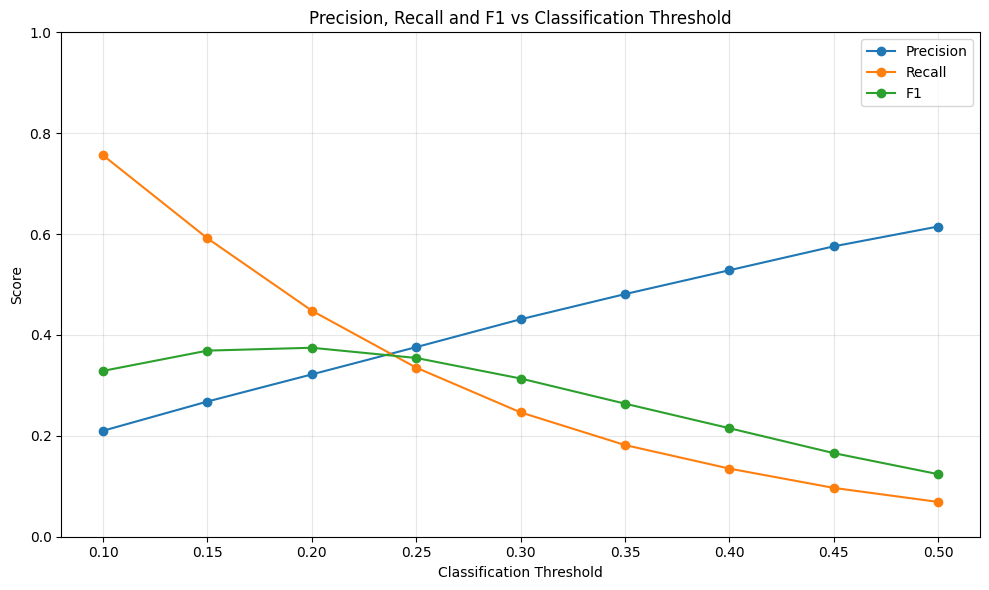

In [52]:
# ============================================
# PRECISION-RECALL-F1 VS THRESHOLD
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='o',
    label='F1'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Classification Threshold')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
!pip install mlflow -q
import numpy as np
import pandas as pd
import numba
import shap
import mlflow

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Numba:", numba.__version__)
print("SHAP:", shap.__version__)
print("MLflow:", mlflow.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [54]:
import shap

print("SHAP imported successfully!")
print("SHAP version:", shap.__version__)

SHAP imported successfully!
SHAP version: 0.52.0


In [55]:
# ============================================
# EXPLAINABLE AI — SHAP SETUP
# ============================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

print("\nTraining data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

SHAP version: 0.52.0

Training data shape: (204277, 39)
Testing data shape: (51070, 39)


In [56]:
# ============================================
# SHAP FEATURE NAMES
# ============================================

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed Feature Names:")
for i, feature in enumerate(feature_names):
    print(f"{i}: {feature}")

Number of processed features: 39

Processed Feature Names:
0: numerical__Age
1: numerical__Income
2: numerical__LoanAmount
3: numerical__CreditScore
4: numerical__MonthsEmployed
5: numerical__NumCreditLines
6: numerical__InterestRate
7: numerical__LoanTerm
8: numerical__DTIRatio
9: numerical__MonthlyIncome
10: numerical__EstimatedMonthlyDebt
11: numerical__LoanToIncome
12: numerical__CreditToAgeRatio
13: numerical__EmploymentStability
14: numerical__HighRiskCombo
15: numerical__InterestDebtStress
16: numerical__LoanPerCreditLine
17: categorical__Education_Bachelor's
18: categorical__Education_High School
19: categorical__Education_Master's
20: categorical__Education_PhD
21: categorical__EmploymentType_Full-time
22: categorical__EmploymentType_Part-time
23: categorical__EmploymentType_Self-employed
24: categorical__EmploymentType_Unemployed
25: categorical__MaritalStatus_Divorced
26: categorical__MaritalStatus_Married
27: categorical__MaritalStatus_Single
28: categorical__HasMortgage_No

In [57]:
# ============================================
# SHAP LINEAR EXPLAINER
# ============================================

# Use a representative sample for SHAP analysis
shap_sample_size = min(5000, X_train_processed.shape[0])

np.random.seed(42)

shap_indices = np.random.choice(
    X_train_processed.shape[0],
    size=shap_sample_size,
    replace=False
)

X_shap = X_train_processed[shap_indices]

print("SHAP sample shape:", X_shap.shape)

# Create Linear SHAP explainer
explainer = shap.LinearExplainer(
    best_logistic_model,
    X_shap
)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", np.array(shap_values).shape)
print("SHAP analysis completed successfully.")

SHAP sample shape: (5000, 39)
SHAP values shape: (5000, 39)
SHAP analysis completed successfully.


In [58]:
# ============================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ============================================

shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Absolute_SHAP': shap_importance
}).sort_values(
    by='Mean_Absolute_SHAP',
    ascending=False
)

print("Global SHAP Feature Importance")
print("=" * 70)

display(
    shap_importance_df.head(15).round(6)
)

Global SHAP Feature Importance


,Feature,Mean_Absolute_SHAP
0,numerical__Age,0.516646
6,numerical__InterestRate,0.404410
11,numerical__LoanToIncome,0.318641
4,numerical__MonthsEmployed,0.277034
38,categorical__HasCoSigner_Yes,0.235231
31,categorical__HasDependents_Yes,0.233567
29,categorical__HasMortgage_Yes,0.207377
21,categorical__EmploymentType_Full-time,0.152428
26,categorical__MaritalStatus_Married,0.150737
28,categorical__HasMortgage_No,0.130712


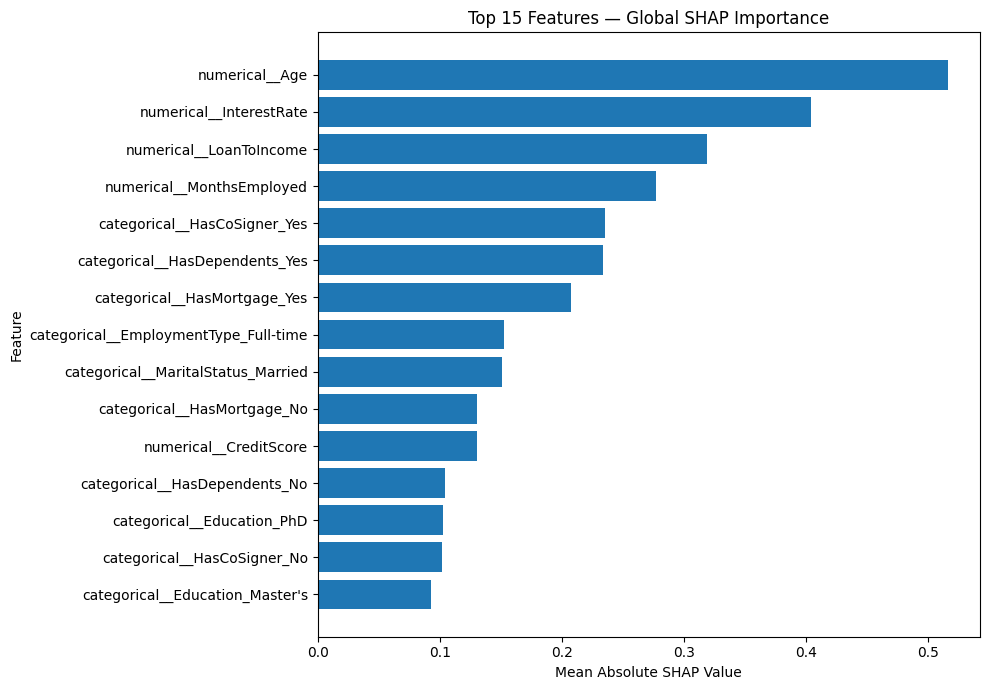

In [59]:
# ============================================
# SHAP GLOBAL IMPORTANCE PLOT
# ============================================

top_features = shap_importance_df.head(15).sort_values(
    by='Mean_Absolute_SHAP'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Mean_Absolute_SHAP']
)

plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.title('Top 15 Features — Global SHAP Importance')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3819/3747227846.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


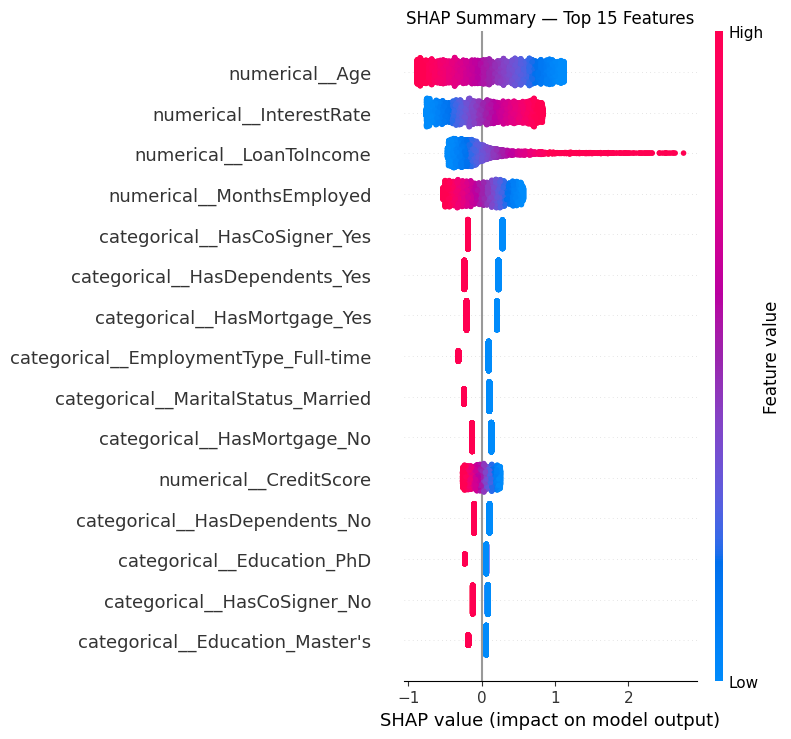

In [60]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title('SHAP Summary — Top 15 Features')
plt.tight_layout()
plt.show()

In [61]:
# ============================================
# INDIVIDUAL BORROWER SHAP EXPLANATION
# ============================================

# Select one test applicant
applicant_index = 0

applicant_data = X_test_processed[applicant_index:applicant_index + 1]

# Generate SHAP explanation
applicant_shap_values = explainer.shap_values(applicant_data)

# Convert to 1D array
applicant_shap_values = np.array(applicant_shap_values).flatten()

# Get applicant probability
applicant_probability = best_logistic_model.predict_proba(
    applicant_data
)[0, 1]

# Create explanation table
applicant_explanation = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': applicant_shap_values,
    'Absolute_SHAP': np.abs(applicant_shap_values)
})

applicant_explanation = applicant_explanation.sort_values(
    by='Absolute_SHAP',
    ascending=False
)

print("Individual Borrower SHAP Explanation")
print("=" * 70)

print(f"Predicted Default Probability: {applicant_probability:.4f}")

print("\nTop 10 Factors Influencing This Prediction:")

display(
    applicant_explanation[
        ['Feature', 'SHAP_Value']
    ].head(10).round(6)
)

Individual Borrower SHAP Explanation
Predicted Default Probability: 0.0302

Top 10 Factors Influencing This Prediction:


,Feature,SHAP_Value
11,numerical__LoanToIncome,0.408983
4,numerical__MonthsEmployed,-0.370976
21,categorical__EmploymentType_Full-time,-0.318638
0,numerical__Age,-0.290773
38,categorical__HasCoSigner_Yes,0.283025
6,numerical__InterestRate,-0.276113
31,categorical__HasDependents_Yes,-0.238262
29,categorical__HasMortgage_Yes,-0.207377
3,numerical__CreditScore,-0.204304
19,categorical__Education_Master's,-0.183415


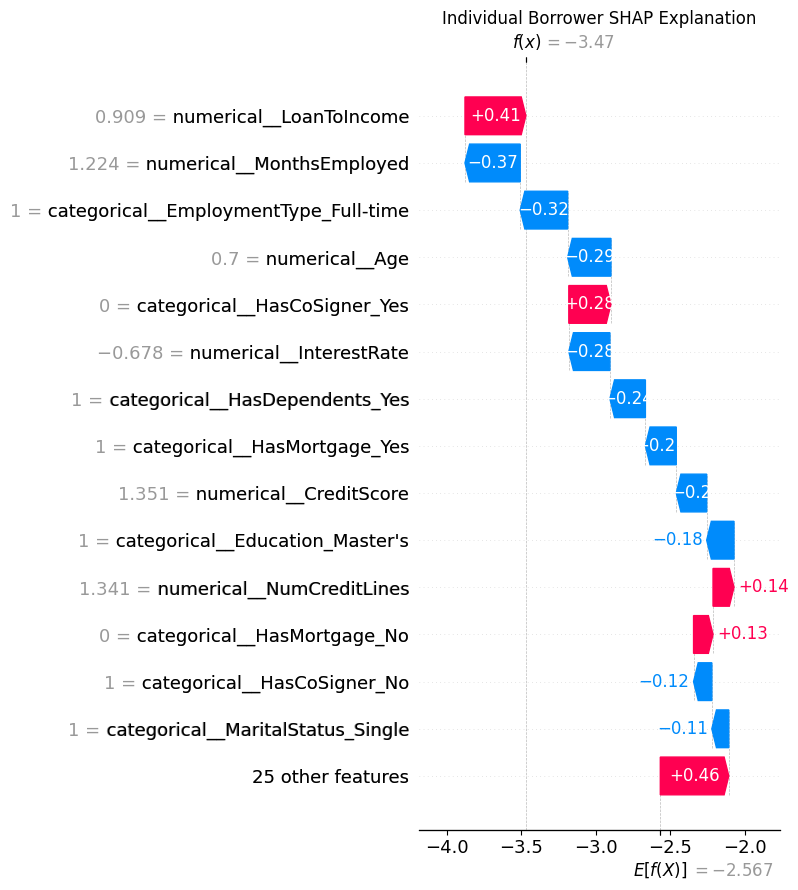

In [62]:
# ============================================
# INDIVIDUAL SHAP WATERFALL
# ============================================

# Create SHAP Explanation object
shap_explanation = shap.Explanation(
    values=applicant_shap_values,
    base_values=explainer.expected_value,
    data=applicant_data.flatten(),
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15,
    show=False
)

plt.title("Individual Borrower SHAP Explanation")
plt.tight_layout()
plt.show()

In [63]:
# ============================================
# READABLE INDIVIDUAL RISK EXPLANATION
# ============================================

top_positive = applicant_explanation[
    applicant_explanation['SHAP_Value'] > 0
].head(5)

top_negative = applicant_explanation[
    applicant_explanation['SHAP_Value'] < 0
].head(5)

print("Individual Risk Explanation")
print("=" * 70)

print(f"Default Probability: {applicant_probability:.2%}")

print("\nFactors Increasing Predicted Risk:")
if len(top_positive) == 0:
    print("No major positive contributors identified.")
else:
    for _, row in top_positive.iterrows():
        print(
            f"+ {row['Feature']}: "
            f"{row['SHAP_Value']:.4f}"
        )

print("\nFactors Decreasing Predicted Risk:")
if len(top_negative) == 0:
    print("No major negative contributors identified.")
else:
    for _, row in top_negative.iterrows():
        print(
            f"- {row['Feature']}: "
            f"{abs(row['SHAP_Value']):.4f}"
        )

Individual Risk Explanation
Default Probability: 3.02%

Factors Increasing Predicted Risk:
+ numerical__LoanToIncome: 0.4090
+ categorical__HasCoSigner_Yes: 0.2830
+ numerical__NumCreditLines: 0.1409
+ categorical__HasMortgage_No: 0.1307
+ categorical__HasDependents_No: 0.1066

Factors Decreasing Predicted Risk:
- numerical__MonthsEmployed: 0.3710
- categorical__EmploymentType_Full-time: 0.3186
- numerical__Age: 0.2908
- numerical__InterestRate: 0.2761
- categorical__HasDependents_Yes: 0.2383


In [64]:
# ============================================
# BIAS / FAIRNESS ANALYSIS
# ============================================

# Use the original test-set rows so group attributes
# remain available for analysis.

X_test_original = X_test.copy()

# Add model predictions and probabilities
bias_analysis_df = X_test_original.copy()

bias_analysis_df['ActualDefault'] = y_test.values
bias_analysis_df['PredictedDefault'] = y_pred_tuned
bias_analysis_df['DefaultProbability'] = y_prob_tuned

print("Bias Detection Dataset")
print("=" * 60)

print("Rows:", len(bias_analysis_df))
print("Columns:", len(bias_analysis_df.columns))

print("\nAvailable categorical groups:")
print(categorical_columns)

Bias Detection Dataset
Rows: 51070
Columns: 27

Available categorical groups:
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [65]:
# ============================================
# GROUP FAIRNESS METRICS
# ============================================

def calculate_group_metrics(data, group_column):

    results = []

    for group_value, group_data in data.groupby(group_column):

        actual_defaults = group_data['ActualDefault'].sum()
        predicted_defaults = group_data['PredictedDefault'].sum()

        results.append({
            'Group': group_value,
            'Count': len(group_data),
            'Actual Default Rate': group_data['ActualDefault'].mean(),
            'Predicted Default Rate': group_data['PredictedDefault'].mean(),
            'Precision': precision_score(
                group_data['ActualDefault'],
                group_data['PredictedDefault'],
                zero_division=0
            ),
            'Recall': recall_score(
                group_data['ActualDefault'],
                group_data['PredictedDefault'],
                zero_division=0
            ),
            'F1': f1_score(
                group_data['ActualDefault'],
                group_data['PredictedDefault'],
                zero_division=0
            )
        })

    return pd.DataFrame(results)

In [66]:
# ============================================
# FAIRNESS ANALYSIS BY GROUP
# ============================================

bias_columns = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

bias_results = {}

for column in bias_columns:

    print("\n" + "=" * 70)
    print(f"Bias Analysis: {column}")
    print("=" * 70)

    metrics = calculate_group_metrics(
        bias_analysis_df,
        column
    )

    bias_results[column] = metrics

    display(metrics.round(4))


Bias Analysis: Education


,Group,Count,Actual Default Rate,Predicted Default Rate,Precision,Recall,F1
0,Bachelor's,12829,0.1225,0.0151,0.6031,0.0744,0.1325
1,High School,12781,0.1299,0.0164,0.5933,0.0747,0.1327
2,Master's,12846,0.1080,0.0103,0.6212,0.0591,0.1080
3,PhD,12614,0.1040,0.0103,0.6615,0.0655,0.1193



Bias Analysis: EmploymentType


,Group,Count,Actual Default Rate,Predicted Default Rate,Precision,Recall,F1
0,Full-time,12724,0.0948,0.0065,0.6145,0.0423,0.0791
1,Part-time,12837,0.1218,0.0146,0.5775,0.0691,0.1234
2,Self-employed,12682,0.1120,0.0113,0.5385,0.0542,0.0985
3,Unemployed,12827,0.1357,0.0196,0.6865,0.0994,0.1736



Bias Analysis: MaritalStatus


...

,Group,Count,Actual Default Rate,Predicted Default Rate,Precision,Recall,F1
0,No,25604,0.1258,0.016,0.6073,0.0773,0.1372
1,Yes,25466,0.1064,0.010,0.6275,0.0590,0.1079



Bias Analysis: LoanPurpose


,Group,Count,Actual Default Rate,Predicted Default Rate,Precision,Recall,F1
0,Auto,10142,0.1206,0.0128,0.6154,0.0654,0.1183
1,Business,10290,0.1197,0.0142,0.5959,0.0706,0.1263
2,Education,10182,0.1183,0.0124,0.6270,0.0656,0.1187
3,Home,10290,0.1017,0.0099,0.6275,0.0612,0.1115
4,Other,10166,0.1205,0.0158,0.6149,0.0808,0.1429



Bias Analysis: HasCoSigner


,Group,Count,Actual Default Rate,Predicted Default Rate,Precision,Recall,F1
0,No,25532,0.1308,0.0172,0.6264,0.0824,0.1456
1,Yes,25538,0.1015,0.0088,0.5929,0.0517,0.0951


In [67]:
# ============================================
# FAIRNESS DISPARITY ANALYSIS
# ============================================

fairness_summary = []

for column, metrics in bias_results.items():

    for metric in ['Precision', 'Recall', 'F1']:

        max_value = metrics[metric].max()
        min_value = metrics[metric].min()

        if min_value > 0:
            disparity_ratio = max_value / min_value
        else:
            disparity_ratio = np.nan

        fairness_summary.append({
            'Attribute': column,
            'Metric': metric,
            'Minimum': min_value,
            'Maximum': max_value,
            'Disparity Ratio': disparity_ratio
        })

fairness_summary_df = pd.DataFrame(fairness_summary)

print("Fairness Disparity Summary")
print("=" * 80)

display(
    fairness_summary_df.round(4)
)

Fairness Disparity Summary


,Attribute,Metric,Minimum,Maximum,Disparity Ratio
0,Education,Precision,0.5933,0.6615,1.1150
1,Education,Recall,0.0591,0.0747,1.2635
2,Education,F1,0.1080,0.1327,1.2290
3,EmploymentType,Precision,0.5385,0.6865,1.2749
4,EmploymentType,Recall,0.0423,0.0994,2.3498
5,EmploymentType,F1,0.0791,0.1736,2.1939
6,MaritalStatus,Precision,0.5828,0.6360,1.0913
7,MaritalStatus,Recall,0.0558,0.0801,1.4343
8,MaritalStatus,F1,0.1019,0.1422,1.3959
9,HasMortgage,Precision,0.6007,0.6250,1.0404


In [68]:
# ============================================
# LARGEST FAIRNESS DISPARITIES
# ============================================

largest_disparities = fairness_summary_df.sort_values(
    by='Disparity Ratio',
    ascending=False
)

print("Largest Observed Group Disparities")
print("=" * 80)

display(
    largest_disparities.head(10).round(4)
)

Largest Observed Group Disparities


,Attribute,Metric,Minimum,Maximum,Disparity Ratio
4,EmploymentType,Recall,0.0423,0.0994,2.3498
5,EmploymentType,F1,0.0791,0.1736,2.1939
19,HasCoSigner,Recall,0.0517,0.0824,1.5931
20,HasCoSigner,F1,0.0951,0.1456,1.5308
7,MaritalStatus,Recall,0.0558,0.0801,1.4343
8,MaritalStatus,F1,0.1019,0.1422,1.3959
16,LoanPurpose,Recall,0.0612,0.0808,1.3208
13,HasDependents,Recall,0.0590,0.0773,1.3094
10,HasMortgage,Recall,0.0595,0.0772,1.2976
17,LoanPurpose,F1,0.1115,0.1429,1.2812


In [69]:
# ============================================
# FAIRNESS REPORT
# ============================================

print("CREDIT RISK MODEL — FAIRNESS ASSESSMENT")
print("=" * 80)

for attribute in bias_columns:

    metrics = bias_results[attribute]

    print(f"\n{attribute}")
    print("-" * 80)

    for metric in ['Precision', 'Recall', 'F1']:

        min_row = metrics.loc[metrics[metric].idxmin()]
        max_row = metrics.loc[metrics[metric].idxmax()]

        print(
            f"{metric}: "
            f"lowest = {min_row['Group']} ({min_row[metric]:.4f}), "
            f"highest = {max_row['Group']} ({max_row[metric]:.4f})"
        )

print("\nFairness assessment completed.")

CREDIT RISK MODEL — FAIRNESS ASSESSMENT

Education
--------------------------------------------------------------------------------
Precision: lowest = High School (0.5933), highest = PhD (0.6615)
Recall: lowest = Master's (0.0591), highest = High School (0.0747)
F1: lowest = Master's (0.1080), highest = High School (0.1327)

EmploymentType
--------------------------------------------------------------------------------
Precision: lowest = Self-employed (0.5385), highest = Unemployed (0.6865)
Recall: lowest = Full-time (0.0423), highest = Unemployed (0.0994)
F1: lowest = Full-time (0.0791), highest = Unemployed (0.1736)

MaritalStatus
--------------------------------------------------------------------------------
Precision: lowest = Married (0.5828), highest = Divorced (0.6360)
Recall: lowest = Married (0.0558), highest = Divorced (0.0801)
F1: lowest = Married (0.1019), highest = Divorced (0.1422)

HasMortgage
---------------------------------------------------------------------------

In [70]:
print("Risk Scoring Verification")
print("=" * 60)

print("Number of test applicants:", len(y_prob_tuned))
print("Minimum probability:", y_prob_tuned.min())
print("Maximum probability:", y_prob_tuned.max())
print("Mean probability:", y_prob_tuned.mean())

print("\nSelected classification threshold: 0.20")

Risk Scoring Verification
Number of test applicants: 51070
Minimum probability: 0.0034284089639093486
Maximum probability: 0.903319406964422
Mean probability: 0.11701135409404688

Selected classification threshold: 0.20


In [71]:
# ============================================
# RISK SCORE CALCULATION
# ============================================

risk_scores = y_prob_tuned * 100

risk_score_df = pd.DataFrame({
    'DefaultProbability': y_prob_tuned,
    'RiskScore': risk_scores
})

print("Risk Score Calculation")
print("=" * 60)

print("Minimum Risk Score:", risk_scores.min())
print("Maximum Risk Score:", risk_scores.max())
print("Mean Risk Score:", risk_scores.mean())

Risk Score Calculation
Minimum Risk Score: 0.34284089639093485
Maximum Risk Score: 90.3319406964422
Mean Risk Score: 11.701135409404692


In [72]:
# ============================================
# RISK CATEGORIES
# ============================================

def assign_risk_category(probability):

    if probability < 0.10:
        return 'Low Risk'
    elif probability < 0.20:
        return 'Medium Risk'
    else:
        return 'High Risk'


risk_score_df['RiskCategory'] = risk_score_df[
    'DefaultProbability'
].apply(assign_risk_category)

print("Risk Category Distribution")
print("=" * 60)

print(
    risk_score_df['RiskCategory']
    .value_counts()
)

print("\nRisk Category Percentages")
print("=" * 60)

print(
    risk_score_df['RiskCategory']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Risk Category Distribution
RiskCategory
Low Risk       29720
Medium Risk    13091
High Risk       8259
Name: count, dtype: int64

Risk Category Percentages
RiskCategory
Low Risk       58.19
Medium Risk    25.63
High Risk      16.17
Name: proportion, dtype: float64


In [73]:
# ============================================
# RISK SCORING VERIFICATION
# ============================================

print("Risk Scoring Verification")
print("=" * 70)

verification = risk_score_df.groupby(
    'RiskCategory'
).agg(
    Applicants=('RiskScore', 'count'),
    AverageRiskScore=('RiskScore', 'mean'),
    MinimumRiskScore=('RiskScore', 'min'),
    MaximumRiskScore=('RiskScore', 'max')
).sort_values(
    by='AverageRiskScore'
)

display(
    verification.round(4)
)

print("\nRisk scoring system verified successfully.")

Risk Scoring Verification


,Applicants,AverageRiskScore,MinimumRiskScore,MaximumRiskScore
RiskCategory,,,,
Low Risk,29720,5.1106,0.3428,9.9990
Medium Risk,13091,14.1199,10.0001,19.9991
High Risk,8259,31.5832,20.0023,90.3319



Risk scoring system verified successfully.


In [74]:
# ============================================
# RISK CATEGORY PERFORMANCE
# ============================================

risk_score_df['ActualDefault'] = y_test.values

risk_performance = risk_score_df.groupby(
    'RiskCategory'
).agg(
    Applicants=('ActualDefault', 'count'),
    ActualDefaults=('ActualDefault', 'sum'),
    ActualDefaultRate=('ActualDefault', 'mean'),
    AverageRiskScore=('RiskScore', 'mean'),
    AverageDefaultProbability=('DefaultProbability', 'mean')
).sort_values(
    by='AverageRiskScore'
)

print("Risk Category Performance")
print("=" * 80)

display(
    risk_performance.round(4)
)

Risk Category Performance


,Applicants,ActualDefaults,ActualDefaultRate,AverageRiskScore,AverageDefaultProbability
RiskCategory,,,,,
Low Risk,29720,1446,0.0487,5.1106,0.0511
Medium Risk,13091,1827,0.1396,14.1199,0.1412
High Risk,8259,2658,0.3218,31.5832,0.3158


In [75]:
# ============================================
# RISK CATEGORY SEPARATION
# ============================================

risk_performance['DefaultRatePercentage'] = (
    risk_performance['ActualDefaultRate'] * 100
)

print("Observed Default Rate by Risk Category")
print("=" * 70)

for category, row in risk_performance.iterrows():

    print(
        f"{category}: "
        f"{row['DefaultRatePercentage']:.2f}% "
        f"actual default rate"
    )

print("\nRisk scoring validation completed.")

Observed Default Rate by Risk Category
Low Risk: 4.87% actual default rate
Medium Risk: 13.96% actual default rate
High Risk: 32.18% actual default rate

Risk scoring validation completed.


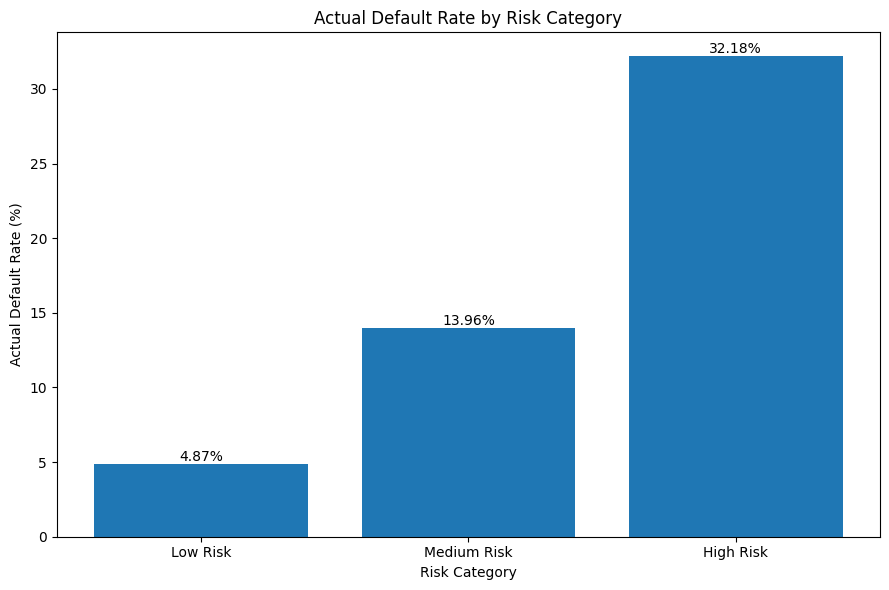

In [76]:
# ============================================
# RISK CATEGORY DEFAULT RATE CHART
# ============================================

plot_data = risk_performance.reset_index()

plt.figure(figsize=(9, 6))

plt.bar(
    plot_data['RiskCategory'],
    plot_data['ActualDefaultRate'] * 100
)

plt.xlabel('Risk Category')
plt.ylabel('Actual Default Rate (%)')
plt.title('Actual Default Rate by Risk Category')

for i, value in enumerate(
    plot_data['ActualDefaultRate'] * 100
):
    plt.text(
        i,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [77]:
# ============================================
# REGULATORY REPORT — PORTFOLIO SUMMARY
# ============================================

total_applicants = len(risk_score_df)
total_defaults = int(risk_score_df['ActualDefault'].sum())

overall_default_rate = (
    total_defaults / total_applicants
)

high_risk_count = (
    risk_score_df['RiskCategory'] == 'High Risk'
).sum()

high_risk_percentage = (
    high_risk_count / total_applicants
)

print("CREDIT RISK REGULATORY REPORT")
print("=" * 80)

print("\n1. PORTFOLIO SUMMARY")
print("-" * 80)

print(f"Total applicants: {total_applicants:,}")
print(f"Total observed defaults: {total_defaults:,}")
print(f"Overall default rate: {overall_default_rate * 100:.2f}%")

print(
    f"High-risk applicants: "
    f"{high_risk_count:,} "
    f"({high_risk_percentage * 100:.2f}%)"
)

CREDIT RISK REGULATORY REPORT

1. PORTFOLIO SUMMARY
--------------------------------------------------------------------------------
Total applicants: 51,070
Total observed defaults: 5,931
Overall default rate: 11.61%
High-risk applicants: 8,259 (16.17%)


In [78]:
# ============================================
# REGULATORY RISK DISTRIBUTION
# ============================================

regulatory_distribution = risk_score_df.groupby(
    'RiskCategory'
).agg(
    Applicants=('ActualDefault', 'count'),
    Defaults=('ActualDefault', 'sum'),
    DefaultRate=('ActualDefault', 'mean'),
    AverageRiskScore=('RiskScore', 'mean')
)

regulatory_distribution[
    'ApplicantPercentage'
] = (
    regulatory_distribution['Applicants']
    / total_applicants * 100
)

print("2. RISK DISTRIBUTION")
print("=" * 80)

display(
    regulatory_distribution.round(4)
)

2. RISK DISTRIBUTION


,Applicants,Defaults,DefaultRate,AverageRiskScore,ApplicantPercentage
RiskCategory,,,,,
High Risk,8259,2658,0.3218,31.5832,16.1719
Low Risk,29720,1446,0.0487,5.1106,58.1946
Medium Risk,13091,1827,0.1396,14.1199,25.6334


In [79]:
# ============================================
# MODEL GOVERNANCE SUMMARY
# ============================================

print("3. MODEL GOVERNANCE & RISK CONTROLS")
print("=" * 80)

print("\nModel:")
print("Logistic Regression")

print("\nEvaluation:")
print(f"ROC-AUC: {0.7617:.4f}")
print(f"PR-AUC: {0.3366:.4f}")
print(f"F1 Score at selected threshold: {0.3746:.4f}")

print("\nExplainability:")
print("SHAP global and individual explanations implemented.")

print("\nFairness:")
print(
    "Group-level fairness analysis performed across "
    "Education, EmploymentType, MaritalStatus, "
    "HasMortgage, HasDependents, LoanPurpose, and HasCoSigner."
)

print("\nRisk Scoring:")
print("Probability-based 0–100 risk score implemented.")
print("Low / Medium / High risk categories implemented.")

print("\nGovernance Recommendations:")
print("1. Monitor model performance periodically.")
print("2. Monitor group-level performance disparities.")
print("3. Review high-risk decisions before adverse action.")
print("4. Maintain model documentation and version history.")
print("5. Revalidate the model when portfolio characteristics change.")
print("6. Do not use automated predictions as the sole basis for credit decisions.")

print("\nRegulatory reporting component completed.")

3. MODEL GOVERNANCE & RISK CONTROLS

Model:
Logistic Regression

Evaluation:
ROC-AUC: 0.7617
PR-AUC: 0.3366
F1 Score at selected threshold: 0.3746

Explainability:
SHAP global and individual explanations implemented.

Fairness:
Group-level fairness analysis performed across Education, EmploymentType, MaritalStatus, HasMortgage, HasDependents, LoanPurpose, and HasCoSigner.

Risk Scoring:
Probability-based 0–100 risk score implemented.
Low / Medium / High risk categories implemented.

Governance Recommendations:
1. Monitor model performance periodically.
2. Monitor group-level performance disparities.
3. Review high-risk decisions before adverse action.
4. Maintain model documentation and version history.
5. Revalidate the model when portfolio characteristics change.
6. Do not use automated predictions as the sole basis for credit decisions.

Regulatory reporting component completed.


In [80]:
import mlflow
import sys

print("Python version:", sys.version)
print("MLflow version:", mlflow.__version__)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
MLflow version: 3.15.2


In [81]:
mlflow.set_experiment("Credit Risk Assessment System")

print("MLflow experiment created/selected successfully.")

2026/08/26 15:46:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/26 15:46:08 INFO mlflow.store.db.utils: Updating database tables
2026/08/26 15:46:13 INFO mlflow.tracking.fluent: Experiment with name 'Credit Risk Assessment System' does not exist. Creating a new experiment.


MLflow experiment created/selected successfully.


In [82]:
print("Runtime restored successfully.")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Available models:")
print("Logistic Regression:", "logistic_model" in globals())
print("Random Forest:", "random_forest_model" in globals())
print("HistGradient Boosting:", "hist_gradient_model" in globals())

Runtime restored successfully.
X_train: (204277, 24)
X_test: (51070, 24)
Available models:
Logistic Regression: True
Random Forest: False
HistGradient Boosting: False


In [83]:
print("Logistic Regression model:")
print(logistic_model)

print("\nModel parameters:")
print(logistic_model.get_params())

Logistic Regression model:
LogisticRegression(max_iter=1000, random_state=42)

Model parameters:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [84]:
print("Tuned Logistic Regression:", "tuned_logistic_model" in globals())

if "tuned_logistic_model" in globals():
    print(tuned_logistic_model)
    print("\nTuned parameters:")
    print(tuned_logistic_model.get_params())

Tuned Logistic Regression: False


In [85]:
from sklearn.linear_model import LogisticRegression

tuned_logistic_model = LogisticRegression(
    C=0.0745934328572655,
    class_weight=None,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

tuned_logistic_model.fit(X_train_processed, y_train)

print("Tuned Logistic Regression recreated successfully.")
print(tuned_logistic_model)

Tuned Logistic Regression recreated successfully.
LogisticRegression(C=0.0745934328572655, max_iter=1000, random_state=42,
                   solver='liblinear')


In [86]:
print("Tuned model parameters:")
print(tuned_logistic_model.get_params())

print("\nModel fitted:", hasattr(tuned_logistic_model, "coef_"))
print("Number of coefficients:", tuned_logistic_model.coef_.shape)

Tuned model parameters:
{'C': 0.0745934328572655, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Model fitted: True
Number of coefficients: (1, 39)


In [87]:
# ============================================
# FINAL MODEL PREDICTIONS
# ============================================

import numpy as np

# Generate probability predictions
y_prob_tuned = tuned_logistic_model.predict_proba(X_test_processed)[:, 1]

# Standard 0.50 classification predictions
y_pred_default = (y_prob_tuned >= 0.50).astype(int)

# Selected operational classification threshold
selected_threshold = 0.20

# Predictions using the selected threshold
y_pred_threshold = (y_prob_tuned >= selected_threshold).astype(int)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_threshold))
print("Number of probabilities:", len(y_prob_tuned))

print(
    "Probability range:",
    y_prob_tuned.min(),
    "to",
    y_prob_tuned.max()
)

print("Default classification threshold: 0.50")
print("Selected operational threshold:", selected_threshold)

print("Predicted defaults at 0.50:", y_pred_default.sum())
print("Predicted defaults at 0.20:", y_pred_threshold.sum())

Predictions generated successfully.
Number of predictions: 51070
Number of probabilities: 51070
Probability range: 0.0034284089639093486 to 0.903319406964422
Default classification threshold: 0.50
Selected operational threshold: 0.2
Predicted defaults at 0.50: 665
Predicted defaults at 0.20: 8259


In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

mlflow_accuracy = accuracy_score(y_test, y_pred_tuned)
mlflow_precision = precision_score(y_test, y_pred_tuned)
mlflow_recall = recall_score(y_test, y_pred_tuned)
mlflow_f1 = f1_score(y_test, y_pred_tuned)
mlflow_roc_auc = roc_auc_score(y_test, y_prob_tuned)
mlflow_pr_auc = average_precision_score(y_test, y_prob_tuned)

print("Final Tuned Model Metrics")
print("=" * 60)
print(f"Accuracy:  {mlflow_accuracy:.4f}")
print(f"Precision: {mlflow_precision:.4f}")
print(f"Recall:    {mlflow_recall:.4f}")
print(f"F1:        {mlflow_f1:.4f}")
print(f"ROC-AUC:   {mlflow_roc_auc:.4f}")
print(f"PR-AUC:    {mlflow_pr_auc:.4f}")

Final Tuned Model Metrics
Accuracy:  0.8869
Precision: 0.6150
Recall:    0.0690
F1:        0.1240
ROC-AUC:   0.7617
PR-AUC:    0.3366


In [89]:
import mlflow

# Select the existing experiment
mlflow.set_experiment("Credit Risk Assessment System")

# Start an MLflow run
with mlflow.start_run(run_name="Tuned Logistic Regression"):

    # Log hyperparameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("C", 0.0745934328572655)
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "None")
    mlflow.log_param("max_iter", 1000)

    # Log project/model information
    mlflow.log_param("training_samples", X_train_processed.shape[0])
    mlflow.log_param("test_samples", X_test_processed.shape[0])
    mlflow.log_param("processed_features", X_train_processed.shape[1])

    # Log classification threshold
    mlflow.log_param("classification_threshold", 0.20)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", mlflow_accuracy)
    mlflow.log_metric("precision", mlflow_precision)
    mlflow.log_metric("recall", mlflow_recall)
    mlflow.log_metric("f1", mlflow_f1)
    mlflow.log_metric("roc_auc", mlflow_roc_auc)
    mlflow.log_metric("pr_auc", mlflow_pr_auc)

    # Log model
    mlflow.sklearn.log_model(
        tuned_logistic_model,
        name="credit_risk_logistic_regression"
    )

    print("MLflow run completed successfully.")
    print("Run ID:", mlflow.active_run().info.run_id)

MLflow run completed successfully.
Run ID: eb1c8b69feef4f4bbf5750f08d069fa3


In [90]:
print("MLflow verification")
print("=" * 60)

experiment = mlflow.get_experiment_by_name(
    "Credit Risk Assessment System"
)

print("Experiment ID:", experiment.experiment_id)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

print("Number of runs:", len(runs))

display(
    runs[
        [
            "run_id",
            "status",
            "metrics.accuracy",
            "metrics.f1",
            "metrics.roc_auc",
            "metrics.pr_auc",
            "params.C",
            "params.solver"
        ]
    ]
)

MLflow verification
Experiment ID: 1
Number of runs: 1


,run_id,status,metrics.accuracy,metrics.f1,metrics.roc_auc,metrics.pr_auc,params.C,params.solver
0,eb1c8b69feef4f4bbf5750f08d069fa3,FINISHED,0.886861,0.124015,0.761673,0.336608,0.0745934328572655,liblinear


In [91]:
# ============================================
# RUNTIME STATE CHECK
# ============================================

print("Runtime state check")
print("=" * 60)

variables_to_check = [
    "df_engineered",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_train_processed",
    "X_test_processed",
    "preprocessor",
    "trained_models",
    "best_logistic_model",
    "tuned_results",
    "y_pred_tuned",
    "y_prob_tuned"
]

for var in variables_to_check:
    print(f"{var}: {'AVAILABLE' if var in globals() else 'NOT AVAILABLE'}")

Runtime state check
df_engineered: AVAILABLE
X_train: AVAILABLE
X_test: AVAILABLE
y_train: AVAILABLE
y_test: AVAILABLE
X_train_processed: AVAILABLE
X_test_processed: AVAILABLE
preprocessor: AVAILABLE
trained_models: AVAILABLE
best_logistic_model: AVAILABLE
tuned_results: AVAILABLE
y_pred_tuned: AVAILABLE
y_prob_tuned: AVAILABLE
